<a id='0'></a>
# 1. Problem Definition

# Problem Definition

The objective of this project is to develop a machine learning model capable of estimating the future weekly return of Microsoft stock using historical market information and features derived from financial time series data.

The problem is formulated as a supervised learning task for financial time series forecasting.

The target variable is defined as the future weekly return:

$$
R_{t+1} = \frac{P_{t+1}-P_t}{P_t}
$$

where:

- $P_t$ is the closing price at week $t$
- $R_{t+1}$ is the return observed in the following week

The predictive variables (*features*) may include:

- lagged returns
- rolling volatility
- momentum indicators
- moving averages
- technical indicators
- trading volume
- market-related variables
- macroeconomic information

The practical objective is not to predict prices with certainty, but rather to identify statistical relationships that may contain incremental predictive information useful for investment decision-making, trading strategies, and portfolio management.

---

# Nature of Financial Time Series Prediction

Financial markets present several characteristics that make prediction particularly difficult:

- high levels of noise
- low signal-to-noise ratio
- non-stationarity
- structural breaks
- regime changes
- temporal dependence
- sensitivity to exogenous events

Unlike many traditional machine learning problems, financial prediction operates in environments where the underlying data-generating process may evolve over time.

As discussed in the financial econometrics literature, market efficiency implies that predictable patterns, if they exist, are often weak, unstable, and rapidly arbitraged away.

Therefore, the objective is not perfect prediction, but the extraction of weak statistical signals with potential economic value.

---

# Type of Machine Learning Problem

This problem can be approached in two different ways.

## Regression

Predicting the numerical value of the future return:

$$
\hat{R}_{t+1}
$$

## Classification

Predicting only the direction of the market movement:

$$
Y=
\begin{cases}
1 & \text{if } R_{t+1}>0 \\
0 & \text{if } R_{t+1}\leq0
\end{cases}
$$

In many practical trading applications, directional prediction may be more useful than estimating the exact magnitude of returns.

---

# Research Hypothesis

The central hypothesis of this project is based on the empirical finance and financial machine learning literature:

> Although financial markets are highly noisy and approximately efficient, historical market data may still contain weak and partially persistent statistical dependencies that can be exploited using machine learning techniques.

This idea is closely related to:

- financial econometrics
- weak-form market efficiency
- behavioral finance
- statistical learning
- quantitative finance

The project follows the perspective that financial machine learning is primarily concerned with:

- detecting probabilistic patterns
- estimating conditional distributions
- identifying predictive signals with economic relevance

rather than attempting deterministic prediction of market prices.

---

# Theoretical Motivation

This project is inspired by concepts from:

- statistical learning theory
- empirical asset pricing
- financial econometrics
- machine learning applied to quantitative finance

including ideas discussed in works such as:

- *Advances in Financial Machine Learning* by : Marcos López de Prado.
- *Machine Learning and Data Science Blueprints for Finance* by : Hariom Tatsat, Sahil Puri and Brad Lookabaugh.
- empirical studies on return predictability and market efficiency

<a id='1'></a>
# 2. Getting Started- Loading the data and python packages

<a id='1.1'></a>
## 2.1. Loading the python packages

In [ ]:
!pip install scikeras tensorflow scikit-learn

In [ ]:
# ============================================
# Core Libraries
# ============================================

import numpy as np
import pandas as pd

# ============================================
# Data Sources
# ============================================

import yfinance as yf

# ============================================
# Visualization
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf

# Visualization Style
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ============================================
# Scikit-Learn: Preprocessing
# ============================================

from sklearn.preprocessing import StandardScaler

# ============================================
# Scikit-Learn: Model Selection
# ============================================

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    cross_val_score,
    GridSearchCV
)

# ============================================
# Scikit-Learn: Regression Models
# ============================================

from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

from sklearn.neural_network import MLPRegressor

# ============================================
# Deep Learning
# ============================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Dropout
)

from tensorflow.keras.optimizers import SGD, Adam

from scikeras.wrappers import KerasRegressor

# ============================================
# Statistical Models
# ============================================

import statsmodels.api as sm

from statsmodels.tsa.arima.model import ARIMA

# ============================================
# Feature Selection
# ============================================

from sklearn.feature_selection import (
    SelectKBest,
    f_regression
)

# ============================================
# Metrics
# ============================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ============================================
# Model Persistence
# ============================================

from pickle import dump, load

# ============================================
# General Configuration
# ============================================

import warnings
warnings.filterwarnings("ignore")

# Random Seed for Reproducibility
SEED = 42
np.random.seed(SEED)

# Libraries and Environment Configuration

This section imports the main libraries used throughout the project.

The notebook combines tools from:

- financial data analysis
- statistical modeling
- machine learning
- deep learning
- time series analysis
- data visualization

The objective is to build a complete quantitative research workflow for financial return prediction.

---

# Numerical and Data Manipulation Libraries

The project relies on the scientific Python ecosystem for numerical computation and tabular data processing.

## NumPy

Used for:

- numerical operations
- matrix computations
- vectorized calculations
- logarithmic return transformations

## Pandas

Used for:

- financial time series manipulation
- dataset alignment
- missing value handling
- feature engineering
- resampling and indexing

These libraries form the foundation of most quantitative finance workflows in Python.

---

# Financial Data Sources

## Yahoo Finance

The `yfinance` library is used to retrieve:

- stock prices
- adjusted close prices
- historical market data

This provides direct access to publicly available financial information for equities such as Microsoft, IBM, and Google.

---

# Data Visualization

Visualization plays an important role in financial machine learning because market data often exhibits:

- non-stationarity
- volatility clustering
- outliers
- temporal dependence

The notebook uses:

- `matplotlib`
- `seaborn`
- autocorrelation plots
- scatter matrix visualizations

to explore statistical properties of the financial time series.

The visualization style is configured globally to maintain consistency across charts and figures.

---

# Machine Learning Libraries

The project uses `scikit-learn` as the main machine learning framework.

## Preprocessing

Feature scaling is implemented using:

- `StandardScaler`

Standardization is particularly important for:

- distance-based models
- neural networks
- regularized regression
- support vector machines

---

# Model Selection and Validation

Several tools are included for:

- train-test splitting
- cross-validation
- hyperparameter optimization
- time-series-aware validation

In financial forecasting, preserving temporal order is essential to avoid look-ahead bias and data leakage.

For this reason, `TimeSeriesSplit` is especially important.

---

# Regression Models

The notebook includes a broad family of predictive models:

## Linear Models

- Linear Regression
- Lasso Regression
- Elastic Net

These models provide:

- interpretability
- baseline performance
- regularization capabilities

## Tree-Based Models

- Decision Trees
- Random Forest
- Gradient Boosting
- Extra Trees
- AdaBoost

These methods can capture:

- nonlinear relationships
- interaction effects
- complex feature structures

## Distance and Kernel Methods

- K-Nearest Neighbors
- Support Vector Regression

These models are useful for capturing local and nonlinear patterns in financial data.

## Neural Networks

- Multi-Layer Perceptron (MLP)
- Long Short-Term Memory (LSTM)

Deep learning architectures may capture more complex temporal dynamics, although they also require careful regularization due to the relatively small sample size.

---

# Statistical and Econometric Models

The notebook also incorporates classical econometric approaches using `statsmodels`.

## ARIMA Models

ARIMA models are widely used in financial time series analysis for modeling:

- autocorrelation
- persistence
- temporal dynamics

Including statistical models alongside machine learning models allows comparison between:

- traditional econometrics
- modern predictive learning methods

---

# Feature Selection

Feature selection techniques are included to evaluate the predictive relevance of explanatory variables.

This is important because financial datasets often contain:

- noisy predictors
- weak signals
- unstable relationships

Reducing irrelevant variables may improve generalization performance.

---

# Evaluation Metrics

The project evaluates predictive performance using:

- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- $R^2$

These metrics measure different aspects of prediction quality and model fit.

In financial forecasting, out-of-sample performance is generally more important than in-sample accuracy.

---

# Reproducibility and Stability

A fixed random seed is defined:

$$
SEED = 42
$$

to improve reproducibility of experiments and model training.

Warnings are also suppressed to maintain cleaner notebook outputs during iterative experimentation.

<a id='1.2'></a>
## 2.2. Loading the Data

In [ ]:
# ============================================
# Load Financial Data
# ============================================

# Stocks
stock_tickers = ["MSFT", "IBM", "GOOGL"]

# Currency Pairs (FRED)
currency_tickers = ["DEXJPUS", "DEXUSUK"]

# Market Indices (FRED)
index_tickers = ["SP500", "DJIA", "VIXCLS"]

# Download stock market data from Yahoo Finance
stock_data = yf.download(
    stock_tickers,
    start="2016-01-01",
    end="2026-05-10",
    auto_adjust=True,
    progress=False
)

# Download macroeconomic and market data from FRED
import pandas_datareader.data as web

currency_data = web.DataReader(
    currency_tickers,
    "fred",
    start="2016-01-01",
    end="2026-05-10"
)

index_data = web.DataReader(
    index_tickers,
    "fred",
    start="2016-01-01",
    end="2026-05-10"
)

# ============================================
# Define Prediction Horizon
# ============================================

# Approximate one trading week
return_period = 5

# ============================================
# Define Target Variable (Y)
# ============================================

# Future MSFT weekly log returns
Y = (
    np.log(stock_data["Close"]["MSFT"])
    .diff(return_period)
    .shift(-return_period)
)

Y.name = "MSFT_Future_Return"

# ============================================
# Define Feature Set (X)
# ============================================

# --------------------------------------------
# A. Other Equity Returns
# --------------------------------------------

X1 = (
    np.log(stock_data["Close"][["GOOGL", "IBM"]])
    .diff(return_period)
)

# --------------------------------------------
# B. Currency Returns
# --------------------------------------------

X2 = np.log(currency_data).diff(return_period)

# --------------------------------------------
# C. Market Index Returns
# --------------------------------------------

X3 = np.log(index_data).diff(return_period)

# --------------------------------------------
# D. Microsoft Momentum Features
# --------------------------------------------

momentum_periods = [
    return_period,
    return_period * 3,
    return_period * 6,
    return_period * 12
]

X4 = pd.concat(
    [
        np.log(stock_data["Close"]["MSFT"]).diff(period)
        for period in momentum_periods
    ],
    axis=1
)

X4.columns = [
    "MSFT_1W",
    "MSFT_3W",
    "MSFT_6W",
    "MSFT_12W"
]

# ============================================
# Combine Features
# ============================================

X = pd.concat([X1, X2, X3, X4], axis=1)

# ============================================
# Final Dataset
# ============================================

dataset = pd.concat([Y, X], axis=1)

# Remove missing values
dataset = dataset.dropna()

# Sample every 5 business days
dataset = dataset.iloc[::return_period, :]

# Final Target and Features
Y = dataset[Y.name]
X = dataset[X.columns]

# ============================================
# Dataset Time Coverage
# ============================================

start_date = dataset.index.min()
end_date = dataset.index.max()

years = (end_date - start_date).days / 365.25

print("Dataset Start Date:", start_date.date())
print("Dataset End Date:", end_date.date())
print(f"Total Years Covered: {years:.2f}")

# ============================================
# Dataset Overview
# ============================================

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", Y.shape)



Dataset Start Date: 2016-05-31
Dataset End Date: 2026-04-27
Total Years Covered: 9.91
Feature Matrix Shape: (471, 11)
Target Vector Shape: (471,)


## Financial Data Collection and Feature Engineering

In this section, we construct a financial machine learning dataset for forecasting future Microsoft stock returns. The objective is to predict the future weekly logarithmic return of Microsoft (`MSFT`) using information extracted from multiple segments of the financial system.

The study period spans from **May 31, 2016 to April 27, 2026**, covering approximately **9.9 years** of financial market activity. This interval includes multiple market regimes, such as periods of economic expansion, monetary tightening cycles, the COVID-19 market shock, post-pandemic recovery dynamics, and high-volatility environments associated with inflation and interest rate uncertainty.

Analyzing a long historical window is particularly important in quantitative finance because financial markets are inherently non-stationary. Relationships between variables may evolve over time as macroeconomic conditions, investor expectations, and market structures change.

---

## Theoretical Motivation

Financial asset prices are influenced by a combination of:

- Firm-specific information
- Market-wide risk factors
- Macroeconomic conditions
- Investor sentiment
- Cross-asset interactions

From the perspective of empirical asset pricing and financial econometrics, stock returns cannot be fully understood in isolation. Instead, they are embedded within a broader network of interconnected financial variables.

For this reason, the feature engineering process incorporates information from several domains:

- Equity markets
- Foreign exchange markets
- Broad market indices
- Volatility indicators
- Technical momentum signals

This multi-factor representation is consistent with the theoretical foundations of modern quantitative finance, where return dynamics are often modeled as functions of systematic and idiosyncratic factors.

---

## Data Sources

The dataset combines information from two major financial data providers:

### Yahoo Finance
Used for:
- Equity price data
- Historical adjusted close prices

### FRED (Federal Reserve Economic Data)
Used for:
- Currency exchange rates
- Market indices
- Volatility indicators

The integration of multiple data sources allows the model to incorporate both micro-level and macro-level financial information.

---

## Selected Financial Variables

### Equity Assets
- Microsoft (`MSFT`)
- Google (`GOOGL`)
- IBM (`IBM`)

These companies represent large-cap technology and enterprise-oriented firms with significant influence on U.S. equity markets.

### Currency Variables
- Japanese Yen / U.S. Dollar exchange rate
- U.S. Dollar / British Pound exchange rate

Foreign exchange markets often reflect changes in:
- Global risk sentiment
- Monetary policy expectations
- International capital flows

As a result, currency movements may contain predictive information for equity returns.

### Market Indices and Risk Indicators
- S&P 500 Index (`SP500`)
- Dow Jones Industrial Average (`DJIA`)
- CBOE Volatility Index (`VIX`)

These variables capture aggregate market conditions and investor expectations regarding future uncertainty.

In particular, the VIX index is frequently interpreted as a proxy for market fear and expected volatility.

---

## Target Variable Construction

The target variable (`Y`) is defined as the future logarithmic return of Microsoft stock over a 5-day horizon:

```python
return_period = 5

<a id='2'></a>
# 3. Exploratory Data Analysis

<a id='2.1'></a>
## 3.1. Descriptive Statistics

In [ ]:
# ============================================
# Exploratory Data Analysis (EDA)
# ============================================

# Display numerical precision
pd.set_option("display.precision", 3)

# ============================================
# Descriptive Statistics
# ============================================

print("Descriptive Statistics")
display(dataset.describe())

# ============================================
# First Observations
# ============================================

print("Dataset Preview")
display(dataset.head())

Descriptive Statistics


,MSFT_Future_Return,GOOGL,IBM,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_1W,MSFT_3W,MSFT_6W,MSFT_12W
count,471.000,471.000,471.000,4.710e+02,4.710e+02,471.000,471.000,4.710e+02,471.000,471.000,471.000,471.000
mean,0.005,0.005,0.002,7.368e-04,-2.644e-04,0.002,0.002,2.512e-04,0.005,0.014,0.026,0.053
std,0.031,0.038,0.035,1.255e-02,1.291e-02,0.022,0.022,1.556e-01,0.033,0.053,0.070,0.100
min,-0.156,-0.144,-0.157,-4.592e-02,-8.319e-02,-0.131,-0.164,-4.471e-01,-0.156,-0.185,-0.238,-0.284
25%,-0.012,-0.018,-0.016,-5.982e-03,-7.204e-03,-0.006,-0.007,-8.771e-02,-0.014,-0.014,-0.013,-0.006
50%,0.007,0.008,0.002,9.783e-04,1.578e-04,0.003,0.003,-1.493e-02,0.007,0.018,0.029,0.062
75%,0.023,0.028,0.022,8.455e-03,8.140e-03,0.014,0.012,7.702e-02,0.025,0.041,0.073,0.123
max,0.092,0.136,0.133,4.839e-02,5.530e-02,0.066,0.079,9.920e-01,0.092,0.190,0.246,0.356


Dataset Preview


,MSFT_Future_Return,GOOGL,IBM,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_1W,MSFT_3W,MSFT_6W,MSFT_12W
2016-05-31,-0.017,0.043,0.046,0.007,-0.006,0.010,0.005,-0.016,0.058,0.064,-5.627e-02,0.025
2016-06-08,-0.046,-0.007,0.010,-0.027,0.010,0.009,0.012,-0.008,-0.015,0.030,1.857e-02,-0.015
2016-06-15,0.026,-0.015,-0.022,-0.008,-0.025,-0.023,-0.020,0.358,-0.046,-0.038,5.161e-03,-0.074
2016-06-22,-0.009,-0.030,0.015,-0.012,0.034,0.007,0.008,0.050,0.026,-0.036,6.382e-03,-0.063
2016-06-29,0.016,-0.022,-0.030,-0.018,-0.083,-0.007,-0.005,-0.241,-0.009,-0.029,5.938e-04,-0.070


## Exploratory Data Analysis (EDA)

Before training predictive models, it is essential to perform an exploratory analysis of the dataset. In financial machine learning, exploratory data analysis serves several important purposes:

- Understanding the statistical properties of returns
- Detecting potential anomalies or extreme observations
- Evaluating the scale and variability of features
- Identifying asymmetries and volatility patterns
- Verifying dataset consistency before model estimation

Because financial time series frequently exhibit non-normal behavior, heavy tails, volatility clustering, and regime changes, descriptive analysis is a critical step in the modeling pipeline.

The dataset analyzed in this study covers the period from **May 2016 to April 2026**, incorporating nearly a decade of market dynamics across different economic and financial environments.

---

## Descriptive Statistics

The descriptive statistics provide a first approximation to the distributional properties of the target variable and explanatory features.

Several important characteristics emerge from the results.

### Positive Average Returns

Most equity-related variables exhibit positive mean returns over the sample period.

For example:

- Microsoft future returns show a positive average weekly return of approximately `0.5%`
- Google also presents positive average returns
- Market indices such as the S&P 500 and DJIA display positive long-run drift

This behavior is consistent with the long-term upward tendency historically observed in equity markets due to:

- economic growth,
- productivity improvements,
- technological innovation,
- and corporate earnings expansion.

---

## Volatility Characteristics

The standard deviation values reveal important differences in risk levels across variables.

### Equity Returns

The weekly volatility of Microsoft future returns is approximately:

```python
std ≈ 0.031
```

which indicates moderate short-term variability in stock returns.

Google and IBM exhibit comparable volatility levels, suggesting that these equities operate under similar market risk conditions.

---

### Currency Returns

Currency variables display substantially lower volatility compared to equities.

This result is expected because exchange rates between major developed economies tend to fluctuate within narrower ranges over short horizons.

Nevertheless, even relatively small currency movements can contain valuable macroeconomic information relevant for asset pricing models.

---

### Volatility Index (VIX)

The `VIXCLS` variable exhibits the highest dispersion in the dataset.

This behavior is economically meaningful because the VIX measures expected market volatility and investor uncertainty. During periods of financial stress, the VIX can experience sudden spikes associated with:

- market panic,
- liquidity shocks,
- geopolitical uncertainty,
- or systemic risk events.

The descriptive statistics confirm this characteristic through:

- a very large standard deviation,
- extreme minimum and maximum values,
- and strong asymmetry relative to traditional return series.

This behavior reflects one of the central stylized facts of financial markets: volatility is time-varying and highly clustered.

---

## Distributional Asymmetry and Extreme Values

The minimum and maximum values indicate the presence of large market movements and tail events.

For example:

- Microsoft future returns range from approximately `-15.6%` to `+9.2%`
- The VIX ranges from `-44.7%` to nearly `+99%`

These extreme observations are common in financial datasets and highlight the non-Gaussian nature of asset returns.

In empirical finance, return distributions frequently exhibit:

- fat tails,
- excess kurtosis,
- and asymmetric behavior,

which can create challenges for traditional linear modeling assumptions.

---

## Momentum Features

The momentum variables (`MSFT_1W`, `MSFT_3W`, `MSFT_6W`, `MSFT_12W`) display progressively larger average values as the time horizon increases.

This pattern is economically intuitive because longer accumulation windows capture the persistent upward drift of equity prices over time.

Additionally, volatility increases with longer momentum horizons because cumulative returns aggregate more market variation.

These variables may help the model identify:

- trend persistence,
- medium-term market regimes,
- and behavioral momentum effects documented in financial economics literature.

---

## Dataset Preview

The first observations of the dataset confirm that all variables are properly aligned in time.

Each row represents:

- the information available at a specific date,
- together with the corresponding future Microsoft return to be predicted.

This temporal structure is fundamental in predictive finance because it ensures that the model only uses historical information when forecasting future outcomes.

The preview also illustrates the heterogeneous nature of financial variables:

- equity returns,
- exchange rate movements,
- volatility changes,
- and momentum signals

all coexist within the same feature space.

This heterogeneity is one of the reasons machine learning methods can be particularly valuable in finance, as they are capable of capturing complex nonlinear relationships across diverse financial indicators.

<a id='2.2'></a>
## 3.2. Data Visualization

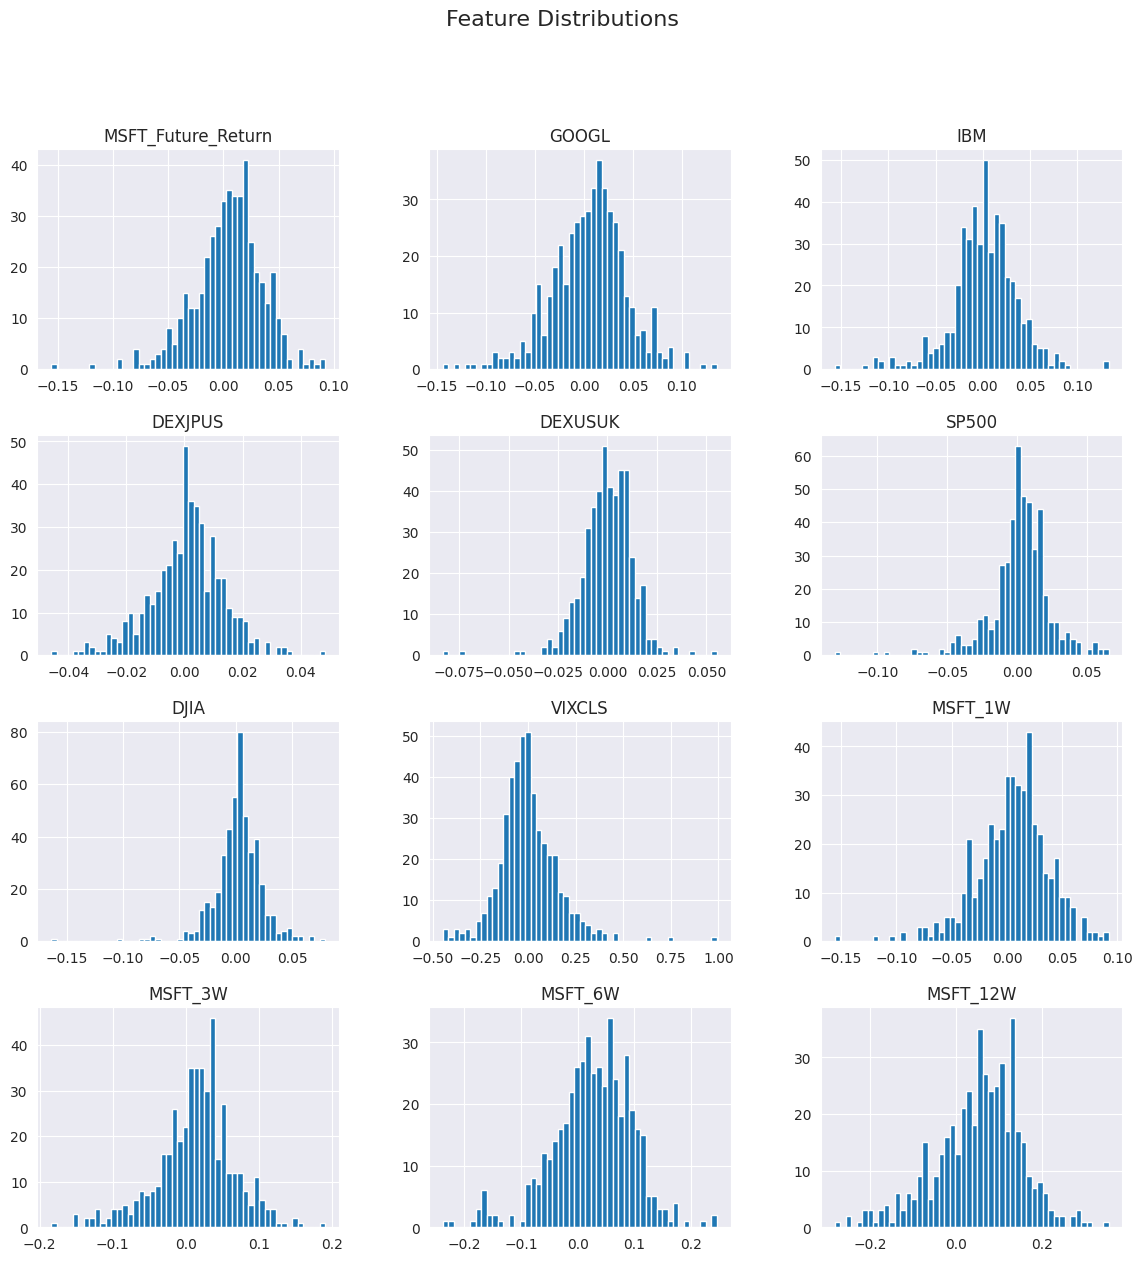

In [ ]:
# ============================================
# Data Visualization
# ============================================

# --------------------------------------------
# Histograms
# --------------------------------------------

dataset.hist(
    bins=50,
    sharex=False,
    sharey=False,
    figsize=(14, 14)
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


## Feature Distribution Analysis

To better understand the statistical behavior of the variables, we visualize the empirical distributions of all features and the target variable using histograms.

Distributional analysis is especially important in quantitative finance because many financial models implicitly assume statistical properties such as:

- normality,
- homoscedasticity,
- and stable variance over time.

However, real financial data often deviates substantially from these assumptions.

The histogram analysis provides a first visual approximation of:

- skewness,
- kurtosis,
- tail behavior,
- volatility asymmetry,
- and the presence of extreme observations.

---

## General Distributional Characteristics

Most variables exhibit distributions centered near zero, which is expected for financial return series computed over relatively short horizons.

This behavior is consistent with one of the central stylized facts of financial markets:

> asset returns fluctuate around small average values while exhibiting substantial short-term variability.

The majority of distributions also display approximately bell-shaped structures, although several variables exhibit visible departures from normality.

---

## Equity Return Distributions

The distributions for:

- `MSFT_Future_Return`
- `GOOGL`
- `IBM`

show relatively symmetric behavior around zero with moderate dispersion.

Nevertheless, the tails are noticeably wider than those expected under a Gaussian distribution. This phenomenon is known as **fat tails** or **leptokurtosis**, a well-documented characteristic of financial returns.

Fat tails imply that extreme market movements occur more frequently than predicted by standard normal models.

This has important implications in:

- risk management,
- portfolio optimization,
- derivative pricing,
- and predictive modeling.

The target variable (`MSFT_Future_Return`) also exhibits slight asymmetry toward negative returns, reflecting the empirical tendency of financial markets to experience abrupt downside shocks during stress periods.

---

## Currency Return Distributions

The exchange rate variables:

- `DEXJPUS`
- `DEXUSUK`

display narrower distributions and lower volatility compared to equities.

This result is economically intuitive because major currency pairs typically fluctuate within smaller percentage ranges over short horizons.

The distributions appear more concentrated around zero, although tail events are still observable.

From a macro-financial perspective, currency variables may still contain predictive information because exchange rates rapidly incorporate expectations regarding:

- interest rates,
- inflation,
- international capital flows,
- and monetary policy decisions.

---

## Market Index Distributions

The `SP500` and `DJIA` distributions exhibit behavior similar to broad equity market returns:

- moderate symmetry,
- concentration near zero,
- and heavier tails than a Gaussian benchmark.

These characteristics reflect the aggregate dynamics of large-cap U.S. equity markets.

The concentration of observations near small positive values is consistent with the long-term upward drift commonly observed in equity indices over extended historical periods.

---

## Volatility Index (VIX) Distribution

The `VIXCLS` distribution differs substantially from the other variables.

Several important characteristics emerge:

- strong positive skewness,
- large dispersion,
- asymmetric tail behavior,
- and extreme positive observations.

This behavior is theoretically expected because volatility indices tend to spike during market crises and uncertainty shocks.

Unlike traditional return series, volatility measures are not symmetric around zero. Instead, they often exhibit sudden upward jumps associated with:

- financial crises,
- liquidity stress,
- macroeconomic uncertainty,
- or panic-driven market conditions.

The presence of large positive outliers in the VIX distribution is therefore economically meaningful rather than anomalous.

This behavior is closely related to the phenomenon of **volatility clustering**, one of the most important empirical regularities in financial econometrics.

---

## Momentum Feature Distributions

The momentum variables:

- `MSFT_1W`
- `MSFT_3W`
- `MSFT_6W`
- `MSFT_12W`

show progressively wider distributions as the accumulation horizon increases.

This occurs because longer lookback windows aggregate more market variation over time.

Several additional patterns are visible:

- increased dispersion for longer horizons,
- slight positive drift,
- and more pronounced tail behavior.

The positive shift in the distributions reflects the long-term upward trend of Microsoft stock over the sample period.

From a financial perspective, these variables attempt to capture medium-term trend persistence and behavioral momentum effects documented extensively in empirical asset pricing literature.

---

## Implications for Machine Learning Models

The histogram analysis reveals that the dataset exhibits several statistical properties commonly observed in financial markets:

- non-normality,
- heavy tails,
- asymmetric behavior,
- and volatility heterogeneity.

These characteristics are important because they may affect model performance and estimation stability.

For example:

- linear models may struggle with nonlinear dependencies,
- extreme observations can influence parameter estimation,
- and time-varying volatility may reduce predictive stability across market regimes.

Consequently, machine learning methods capable of handling nonlinear relationships and complex interactions may provide advantages over traditional econometric approaches when modeling financial return dynamics.

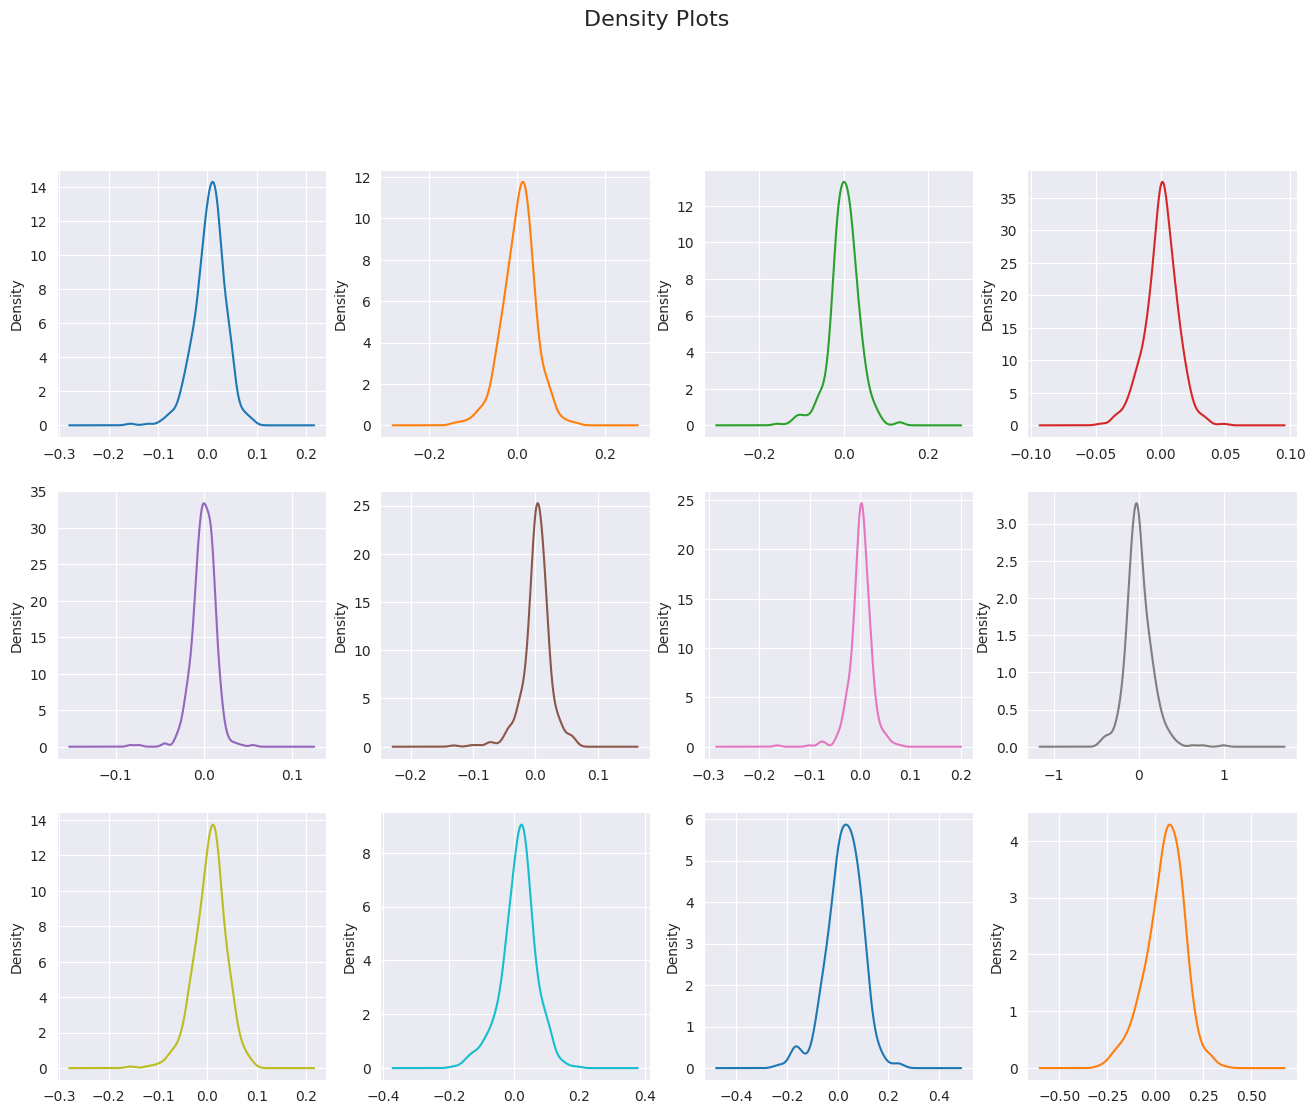

In [ ]:
# ============================================
# Density Plots
# ============================================

dataset.plot(
    kind="density",
    subplots=True,
    layout=(4, 4),
    sharex=False,
    figsize=(16, 16),
    legend=False
)

plt.suptitle("Density Plots", fontsize=16)
plt.show()



## Density Plot Analysis

To complement the histogram analysis, we visualize the empirical probability density functions of all variables using kernel density estimation (KDE).

Density plots provide a smoother representation of the underlying distributions and help identify important statistical characteristics that may not be immediately visible in histograms alone.

In financial econometrics, density analysis is particularly useful for examining:

- tail behavior,
- skewness,
- concentration around the mean,
- multimodality,
- and deviations from Gaussian assumptions.

Because many machine learning and statistical models implicitly rely on distributional assumptions, understanding these empirical properties is essential before model estimation.

---

## Concentration Around Zero

Most variables exhibit strong concentration around values close to zero.

This behavior is expected because short-horizon financial returns typically fluctuate around relatively small average values.

The density peaks observed near zero indicate that:

- small weekly changes occur frequently,
- while large price movements are comparatively rare.

This phenomenon is consistent with the statistical structure commonly observed in financial return series.

---

## Evidence of Heavy Tails

Several distributions exhibit tails that extend significantly beyond the central mass of observations.

This behavior reflects the presence of **fat tails**, one of the most important stylized facts in empirical finance.

Compared to a normal distribution, fat-tailed distributions imply a higher probability of observing extreme market movements.

This characteristic is especially relevant in financial applications because rare but large shocks often dominate:

- portfolio risk,
- drawdowns,
- market crashes,
- and volatility dynamics.

The density plots for:

- `MSFT_Future_Return`,
- `GOOGL`,
- `IBM`,
- and the momentum variables

all display visible tail thickness relative to a purely Gaussian structure.

---

## Asymmetry and Skewness

Several variables also exhibit asymmetric distributions.

### Equity Returns

The equity-related variables show mild negative skewness, indicating that large downside movements may occur more abruptly than positive shocks.

This asymmetry is commonly observed in financial markets and is frequently associated with:
- panic-driven selloffs,
- leverage effects,
- and volatility amplification during market stress periods.

---

### Volatility Index (VIX)

The `VIXCLS` density displays the strongest asymmetry in the dataset.

The distribution is heavily right-skewed, with a long positive tail extending far beyond the central region.

This behavior is theoretically expected because volatility indices tend to experience sudden upward spikes during periods of uncertainty and financial turbulence.

Unlike traditional return series, volatility measures are inherently asymmetric because:
- fear-driven market dynamics generate abrupt volatility expansions,
- while volatility normalization tends to occur more gradually.

The VIX distribution therefore reflects the nonlinear nature of market risk perception.

---

## Narrower Currency Distributions

The currency variables:

- `DEXJPUS`
- `DEXUSUK`

show relatively narrow and sharply peaked density functions.

This indicates:
- lower variance,
- reduced dispersion,
- and more stable short-term fluctuations.

From a macroeconomic perspective, major exchange rates are influenced by:
- interest rate differentials,
- central bank policy,
- inflation expectations,
- and international capital flows.

Although their volatility is lower than that of equities, currency variables may still provide valuable predictive information because foreign exchange markets often react rapidly to new macroeconomic information.

---

## Momentum Feature Dynamics

The momentum variables display progressively wider distributions as the lookback horizon increases:

- `MSFT_1W`
- `MSFT_3W`
- `MSFT_6W`
- `MSFT_12W`

This pattern emerges because longer accumulation windows incorporate more historical market variation.

Several important characteristics are visible:

- increasing variance across horizons,
- smoother density structures,
- and stronger positive drift at longer horizons.

The positive displacement of the densities reflects Microsoft's long-term upward price trend during the study period.

From a financial theory perspective, these features attempt to capture persistent return continuation effects associated with momentum investing strategies.

Momentum effects have been extensively documented in empirical asset pricing literature and remain one of the most robust anomalies observed across financial markets.

---

## Implications for Predictive Modeling

The density analysis confirms that the dataset exhibits several non-Gaussian properties commonly found in financial time series:

- heavy tails,
- skewness,
- volatility asymmetry,
- and heterogeneous variance structures.

These characteristics are important because they may influence the performance of predictive models.

For example:

- linear models may struggle to capture asymmetric relationships,
- extreme observations may distort parameter estimation,
- and non-constant variance can reduce forecasting stability.

Consequently, machine learning methods capable of modeling nonlinear dependencies and complex feature interactions may offer advantages over purely linear econometric approaches in financial prediction tasks.

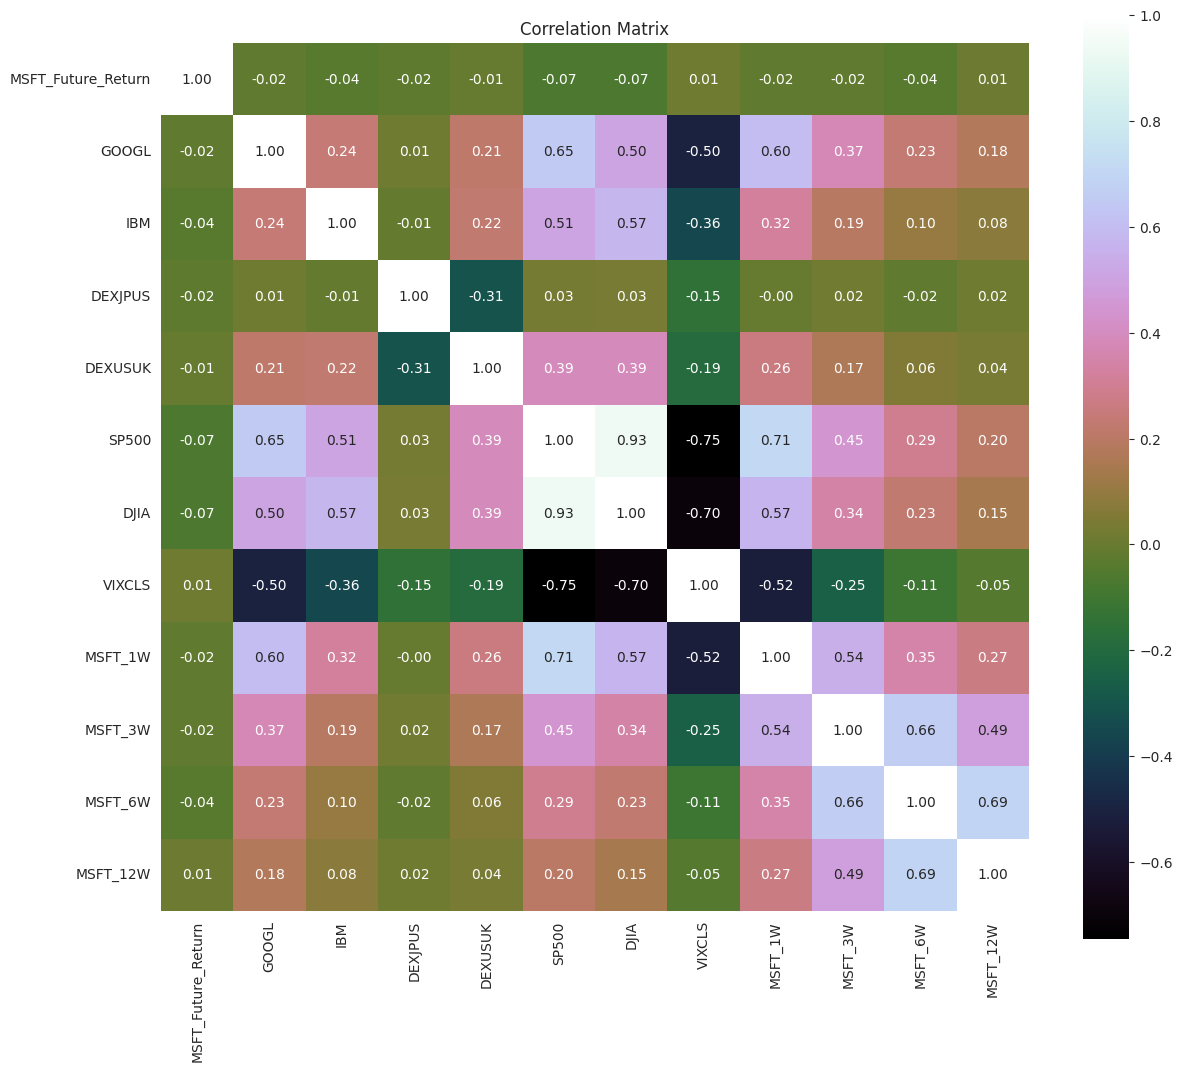

In [ ]:
# ============================================
# Correlation Matrix
# ============================================

correlation = dataset.corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    correlation,
    vmax=1,
    square=True,
    annot=True,
    cmap="cubehelix",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


## Correlation Matrix Analysis

Understanding the relationships between variables is a fundamental step in financial machine learning and econometric modeling.

The correlation matrix provides a first approximation of the linear dependence structure among:

- the target variable,
- cross-asset returns,
- macro-financial indicators,
- volatility measures,
- and momentum features.

In quantitative finance, correlation analysis is particularly important because financial markets are highly interconnected systems in which assets frequently respond to common macroeconomic and behavioral factors.

The heatmap visualization allows us to identify:

- highly related variables,
- potential multicollinearity,
- diversification patterns,
- and economically meaningful dependencies.

---

## Correlation Structure of the Target Variable

One of the most important observations is that the future Microsoft return (`MSFT_Future_Return`) exhibits relatively low contemporaneous linear correlations with the explanatory variables.

Most correlations remain close to zero.

For example:

- correlation with `GOOGL`: approximately `-0.02`
- correlation with `SP500`: approximately `-0.07`
- correlation with `VIXCLS`: approximately `0.01`

This result is highly consistent with financial market theory.

Financial returns are notoriously difficult to predict because markets incorporate information rapidly, a concept closely related to the **Efficient Market Hypothesis (EMH)**.

Low linear correlations suggest that simple linear relationships may not fully capture the predictive structure of the data.

This is one of the main motivations for applying machine learning methods capable of identifying:

- nonlinear interactions,
- conditional dependencies,
- and higher-order patterns.

---

## Strong Correlations Among Equity Market Variables

The analysis reveals substantial positive correlations among equity-related variables.

### S&P 500 and Dow Jones

The strongest relationship appears between:

- `SP500`
- `DJIA`

with a correlation of approximately:

```python
0.93
```

This result is economically intuitive because both indices represent large-cap U.S. equity market performance and are heavily influenced by common macroeconomic factors.

Such high correlations are common among broad market indices.

---

### Technology Stocks and Market Indices

`GOOGL` also exhibits strong positive correlations with:

- `SP500` (`0.65`)
- `DJIA` (`0.50`)
- `MSFT_1W` (`0.60`)

These relationships reflect the interconnected nature of large technology companies within the broader U.S. equity market.

Technology stocks are frequently influenced by:
- investor sentiment,
- monetary policy expectations,
- growth forecasts,
- and sector-wide capital allocation dynamics.

---

## Negative Relationship with the VIX

One of the most economically meaningful patterns is the strong negative correlation between the VIX volatility index and equity market variables.

Examples include:

- `SP500` vs `VIXCLS`: `-0.75`
- `DJIA` vs `VIXCLS`: `-0.70`
- `GOOGL` vs `VIXCLS`: `-0.50`

This inverse relationship is a well-established phenomenon in financial markets.

The VIX is commonly interpreted as a measure of:
- expected future volatility,
- market fear,
- and investor uncertainty.

During periods of market stress:

- equity prices tend to decline,
- while implied volatility rises sharply.

This negative correlation therefore reflects the risk-off dynamics commonly observed during financial turbulence.

---

## Momentum Feature Correlations

The momentum variables exhibit progressively stronger correlations across neighboring horizons.

For example:

- `MSFT_3W` and `MSFT_6W`: `0.66`
- `MSFT_6W` and `MSFT_12W`: `0.69`

This pattern is expected because longer-horizon momentum measures share overlapping historical information.

From a statistical perspective, this may introduce a degree of multicollinearity into the feature space.

However, in machine learning applications, correlated variables are not necessarily problematic. In many cases, correlated momentum signals may still improve predictive performance by capturing trend persistence across different temporal scales.

---

## Currency Variable Relationships

The currency variables display comparatively weaker correlations with equity market features.

For instance:

- `DEXJPUS` exhibits low correlations with most stock-related variables,
- while `DEXUSUK` shows moderate positive relationships with equity indices.

This suggests that foreign exchange variables may contribute complementary macroeconomic information rather than redundant market exposure.

In financial prediction tasks, low-correlation features can sometimes be particularly valuable because they introduce additional sources of information into the model.

---

## Implications for Machine Learning

The correlation matrix reveals several important characteristics of the dataset:

### 1. Weak Linear Predictability

The target variable exhibits limited linear correlation with predictors, suggesting that:
- nonlinear models,
- interaction effects,
- and regime-dependent dynamics

may be necessary to improve forecasting performance.

---

### 2. Presence of Multicollinearity

Some predictors, particularly market indices and momentum variables, display strong intercorrelations.

This may affect:
- coefficient stability in linear regression models,
- interpretability,
- and variance estimation.

Regularization methods or tree-based algorithms may help mitigate these issues.

---

### 3. Economically Meaningful Structure

Despite weak direct predictability, the correlation patterns are economically coherent and consistent with empirical finance theory.

The relationships observed between:
- equities,
- volatility,
- momentum,
- and market indices

closely align with well-documented stylized facts in financial economics.

This consistency increases confidence that the dataset appropriately captures realistic financial market dynamics suitable for predictive modeling experiments.

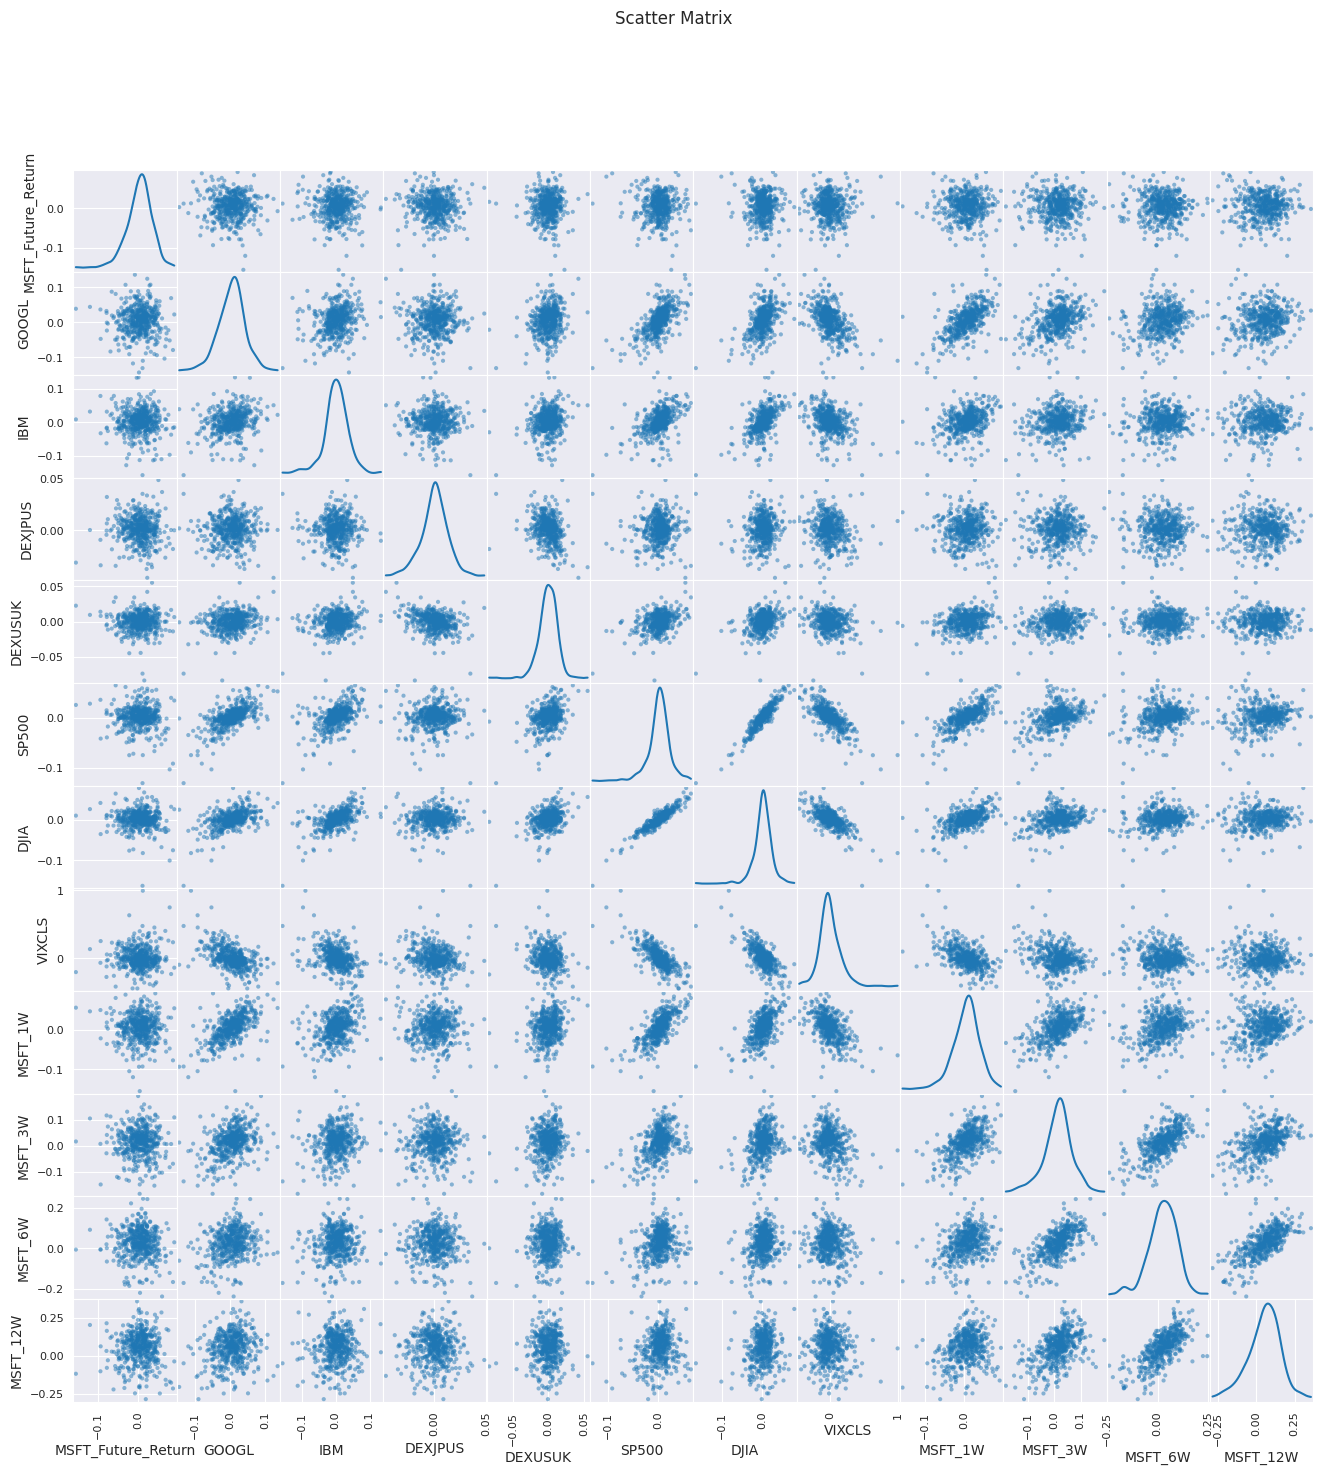

In [ ]:
# ============================================
# Scatter Matrix
# ============================================

scatter_matrix(
    dataset,
    figsize=(16, 16),
    diagonal="kde"
)

plt.suptitle("Scatter Matrix")
plt.show()

## Scatter Matrix Analysis

To further explore the relationships among variables, we construct a scatter matrix combining pairwise scatter plots and kernel density estimations.

The scatter matrix is one of the most informative visualization tools in exploratory financial data analysis because it simultaneously reveals:

- linear relationships,
- nonlinear dependencies,
- volatility structures,
- clustering patterns,
- and potential outliers.

In quantitative finance, visual inspection of pairwise relationships is particularly valuable because financial variables often exhibit complex interactions that are not fully captured by simple summary statistics.

The diagonal panels display the density distributions of each variable, while the off-diagonal panels illustrate pairwise relationships between features.

---

## Weak Predictability of Future Returns

One of the most important observations is that the target variable (`MSFT_Future_Return`) does not exhibit strong visible linear relationships with most explanatory variables.

The scatter plots involving the target variable display:

- high dispersion,
- substantial noise,
- and weak directional structure.

This behavior is highly consistent with empirical financial theory.

Financial markets are characterized by:
- rapid information incorporation,
- high stochasticity,
- and low signal-to-noise ratios.

As a result, future asset returns are notoriously difficult to forecast using simple linear relationships.

The absence of obvious patterns suggests that predictive signals, if they exist, are likely to involve:

- nonlinear dependencies,
- interaction effects,
- conditional dynamics,
- or regime-specific behavior.

This provides additional motivation for the application of machine learning methods capable of modeling complex structures beyond standard linear regression.

---

## Strong Relationships Among Market Variables

Several strong positive relationships are clearly visible among equity-related variables.

### S&P 500 and Dow Jones

The scatter plot between:

- `SP500`
- `DJIA`

shows an almost perfectly linear positive relationship.

This result is economically intuitive because both indices track broad segments of the U.S. equity market and are driven by similar macroeconomic and systemic factors.

The tight clustering around a positive linear trend reflects the strong synchronization commonly observed across major market indices.

---

### Technology and Market Exposure

`GOOGL` also demonstrates positive relationships with:

- `SP500`,
- `DJIA`,
- and Microsoft momentum features.

This behavior reflects the interconnected nature of large-cap technology companies within the broader market ecosystem.

Technology firms are often jointly influenced by:

- monetary policy expectations,
- growth forecasts,
- investor sentiment,
- and institutional portfolio flows.

---

## Negative Relationship Between Equities and Volatility

The scatter plots involving `VIXCLS` reveal strong inverse relationships with equity market variables.

The negative association between:

- `VIXCLS` and `SP500`,
- `VIXCLS` and `DJIA`,
- `VIXCLS` and `GOOGL`

is visually apparent.

This pattern reflects one of the most important empirical regularities in financial markets:

> equity prices and implied volatility tend to move in opposite directions.

During periods of market stress:
- equity prices frequently decline,
- while volatility expectations rise sharply.

The scatter plots clearly illustrate this nonlinear risk-off dynamic.

---

## Momentum Structure Across Time Horizons

The momentum variables exhibit progressively stronger relationships across adjacent horizons.

For example:

- `MSFT_3W` vs `MSFT_6W`
- `MSFT_6W` vs `MSFT_12W`

show relatively concentrated positive structures.

This behavior is expected because these variables contain overlapping historical information.

The plots also suggest that momentum effects may persist across multiple temporal scales, which is consistent with empirical evidence from behavioral finance and momentum investing literature.

The gradual widening of the scatter clouds at longer horizons reflects increasing accumulated variance over time.

---

## Evidence of Heteroskedasticity

Several scatter plots exhibit changes in dispersion across different regions of the feature space.

This phenomenon is known as **heteroskedasticity**, meaning that the variance of observations is not constant.

Heteroskedastic behavior is extremely common in financial markets and is closely related to:

- volatility clustering,
- changing market regimes,
- and time-varying uncertainty.

Periods of market stress often produce:
- larger return magnitudes,
- increased dispersion,
- and greater instability in relationships between variables.

These characteristics can complicate classical econometric modeling assumptions.

---

## Outliers and Extreme Observations

The scatter matrix also reveals the presence of extreme observations and tail events.

Several variables contain isolated points far from the central clusters, particularly:

- volatility-related variables,
- market indices during turbulent periods,
- and longer-horizon momentum measures.

In finance, such outliers are often economically meaningful rather than erroneous data points.

Extreme observations may correspond to:
- market crashes,
- policy shocks,
- liquidity events,
- or periods of elevated systemic risk.

Handling these events appropriately is critical in predictive financial modeling because tail events frequently dominate real-world investment risk.

---

## Implications for Machine Learning Models

The scatter matrix highlights several important properties of the dataset:

### 1. Weak Simple Linear Structure

The absence of strong visible linear relationships with the target variable suggests that prediction may require:
- nonlinear modeling,
- feature interactions,
- and more flexible learning algorithms.

---

### 2. Presence of Structured Market Dependencies

Strong relationships among market variables indicate that the dataset captures realistic financial interconnectedness.

This is important because financial assets rarely evolve independently.

---

### 3. Non-Gaussian and Heteroskedastic Behavior

The combination of:
- heavy tails,
- asymmetric relationships,
- volatility clustering,
- and changing variance structures

suggests that traditional linear assumptions may be insufficient for capturing the full dynamics of the data.

Machine learning methods designed to model nonlinear and high-dimensional interactions may therefore provide advantages in forecasting financial return behavior.

<a id='2.3'></a>
## 3.3. Time Series Analysis

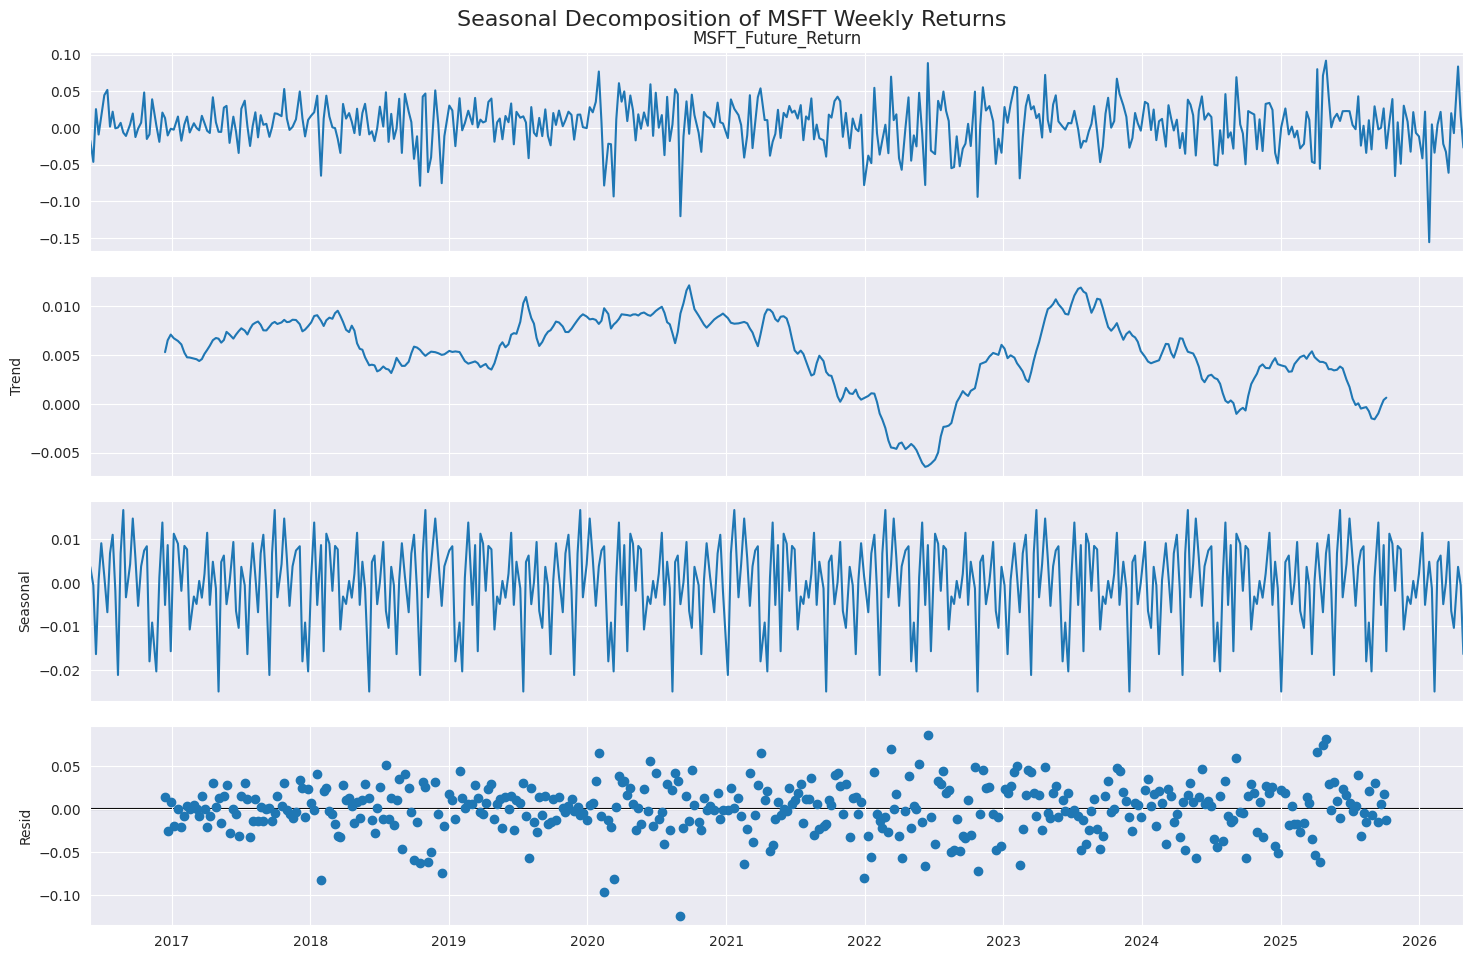

In [ ]:
# ============================================
# Time Series Analysis
# ============================================

from statsmodels.tsa.seasonal import seasonal_decompose

# --------------------------------------------
# Seasonal Decomposition
# --------------------------------------------

decomposition = seasonal_decompose(
    Y,
    model="additive",
    period=52
)

# ============================================
# Plot Components
# ============================================

fig = decomposition.plot()

fig.set_size_inches(15, 10)

plt.suptitle(
    "Seasonal Decomposition of MSFT Weekly Returns",
    fontsize=16
)

plt.show()

## Time Series Decomposition of Microsoft Weekly Returns

To better understand the temporal structure of Microsoft weekly returns, we perform a classical seasonal decomposition of the time series.

Time series decomposition separates the observed series into several underlying components:

- Trend
- Seasonal
- Residual (irregular component)

Using an additive decomposition model, the observed series can be represented as:

```python
Observed = Trend + Seasonal + Residual
```

This methodology is widely used in financial econometrics and time series analysis because it helps identify whether market behavior contains:

- long-term structural movements,
- recurring seasonal patterns,
- or irregular stochastic fluctuations.

The decomposition is performed using a periodicity of:

```python
period = 52
```

which approximates the number of trading weeks in one year.

This allows the analysis to capture potential annual seasonal effects in Microsoft returns.

---

## Observed Series

The first panel displays the original weekly return series for Microsoft.

Several important characteristics are immediately visible:

- returns fluctuate around relatively small average values,
- volatility changes over time,
- and extreme observations occasionally emerge.

The series exhibits substantial short-term variability, which is a defining characteristic of financial return processes.

Large positive and negative movements appear intermittently throughout the sample period, reflecting the influence of:

- macroeconomic events,
- monetary policy changes,
- market sentiment shifts,
- earnings announcements,
- and systemic shocks.

The presence of volatility clustering is also visually apparent, as periods of calm are followed by intervals of elevated market turbulence.

---

## Trend Component

The trend component captures the long-run evolution of the series after smoothing short-term fluctuations.

Several observations emerge from the trend analysis:

- the underlying trend remains relatively close to zero,
- moderate cyclical movements are visible,
- and no strong deterministic upward or downward trajectory dominates the sample.

This behavior is theoretically consistent with financial return series.

Unlike asset prices, which often display persistent long-term growth, return series are generally closer to stationary processes fluctuating around relatively stable means.

Nevertheless, the trend component reveals periods where average returns temporarily become:

- more positive,
- or more negative,

suggesting the existence of changing market regimes across the study period.

For example:

- stronger positive trends appear during bullish market environments,
- while weaker or negative trends emerge during periods of market stress and uncertainty.

These regime transitions are common in financial markets and represent an important challenge for predictive modeling.

---

## Seasonal Component

The seasonal component attempts to capture recurring periodic structures repeating approximately every 52 weeks.

The estimated seasonal fluctuations appear relatively small compared to the total variability of the series.

This result suggests that Microsoft weekly returns do not exhibit strong deterministic annual seasonality.

From a financial perspective, this finding is not surprising.

Short-horizon equity returns are typically dominated by:
- news arrivals,
- investor expectations,
- macroeconomic shocks,
- and stochastic market dynamics,

rather than by highly stable seasonal cycles.

Nevertheless, mild recurrent fluctuations are still observable, which may reflect:
- calendar effects,
- recurring earnings cycles,
- institutional rebalancing patterns,
- or behavioral trading dynamics.

---

## Residual Component

The residual component contains the portion of the series not explained by either the trend or seasonal structure.

Several important characteristics are visible:

- residuals remain highly dispersed,
- extreme observations persist,
- and volatility varies over time.

This indicates that a substantial proportion of Microsoft return dynamics is driven by irregular stochastic behavior rather than deterministic components.

The residual plot also reveals:

- heavy-tailed behavior,
- volatility clustering,
- and occasional extreme shocks.

These features are consistent with well-known stylized facts of financial time series documented extensively in empirical finance literature.

In particular, the presence of volatility clustering suggests that periods of elevated uncertainty tend to persist through time rather than occurring independently.

---

## Implications for Financial Modeling

The decomposition analysis provides several important insights regarding the structure of Microsoft weekly returns.

### 1. Limited Deterministic Structure

The relatively weak seasonal component suggests that deterministic seasonal patterns may contribute only modest predictive information.

This reinforces the idea that financial markets are largely driven by stochastic processes and rapidly changing information flows.

---

### 2. Time-Varying Market Regimes

The evolving trend component indicates that market behavior changes across time.

Such regime shifts are common in finance and may reduce the stability of predictive relationships.

Models trained in one market environment may therefore generalize poorly to different economic conditions.

---

### 3. Dominance of Irregular Fluctuations

The residual component remains highly volatile, highlighting the difficulty of forecasting financial returns.

A large portion of market dynamics appears to be influenced by:
- unpredictable information shocks,
- behavioral responses,
- and nonlinear market interactions.

---

### 4. Motivation for Advanced Machine Learning Methods

Because the decomposition reveals:
- weak deterministic seasonality,
- nonlinear variability,
- heteroskedastic behavior,
- and changing regimes,

more flexible machine learning approaches may be better suited than traditional linear models for capturing complex financial dynamics.

Methods capable of adapting to:
- nonlinear structures,
- interaction effects,
- and time-varying relationships

may provide stronger predictive performance in financial forecasting applications.

<a id='3'></a>
## 4. Data Preparation

<a id='3.2'></a>
## 4.2. Feature Selection

In [ ]:
# ============================================
# Feature Selection
# ============================================

# Select the top predictive features
best_features = SelectKBest(
    score_func=f_regression,
    k=5
)

# Fit feature selection
fit = best_features.fit(X, Y)

# ============================================
# Feature Scores
# ============================================

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": fit.scores_
})

# Sort features by importance
feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

# ============================================
# Display Top Features
# ============================================

print("Top Predictive Features")

display(
    feature_scores
    .head(10)
    .set_index("Feature")
)

Top Predictive Features


,Score
Feature,
DJIA,2.087
SP500,2.007
IBM,0.841
MSFT_6W,0.746
DEXJPUS,0.261
MSFT_1W,0.231
MSFT_3W,0.205
GOOGL,0.156
VIXCLS,0.084


## Feature Selection Using Statistical Tests

In financial machine learning, feature selection is an important step because financial datasets often contain:

- noisy variables,
- weak predictive signals,
- redundant information,
- and highly correlated features.

Selecting the most informative predictors can improve:

- model interpretability,
- computational efficiency,
- generalization performance,
- and robustness against overfitting.

To identify the most relevant explanatory variables, we apply the `SelectKBest` method using the `f_regression` scoring function.

---

## Theoretical Background

The `f_regression` method evaluates the linear relationship between each predictor and the target variable individually.

For each feature, the method computes an F-statistic based on linear regression:

```python
F = \frac{\text{Explained Variance}}{\text{Unexplained Variance}}
```

Higher scores indicate stronger linear explanatory power with respect to the target variable.

In this case, the target variable is:

```python
MSFT_Future_Return
```

which represents future weekly logarithmic returns of Microsoft stock.

The procedure selects the top:

```python
k = 5
```

features according to their statistical scores.

---

## Interpretation of Results

The feature ranking reveals several important insights regarding the structure of predictive information in the dataset.

### Strongest Predictors

The variables with the highest scores are:

| Feature | Score |
|---|---|
| DJIA | 2.087 |
| SP500 | 2.007 |
| IBM | 0.841 |
| MSFT_6W | 0.746 |
| DEXJPUS | 0.261 |

The results suggest that broad market conditions contain more predictive information for future Microsoft returns than most individual technical indicators.

---

## Importance of Market Indices

The two highest-ranked variables are:

- `DJIA`
- `SP500`

This result is economically intuitive because Microsoft is a large-cap U.S. technology company heavily integrated into the broader equity market.

Major market indices capture:

- aggregate investor sentiment,
- macroeconomic expectations,
- liquidity conditions,
- and systematic market risk.

Their relatively stronger predictive contribution suggests that Microsoft's future returns may depend more on general market conditions than on isolated firm-specific dynamics.

From the perspective of asset pricing theory, this is consistent with the importance of systematic risk factors in explaining stock return behavior.

---

## Cross-Asset Information

The inclusion of `IBM` among the top-ranked features suggests the presence of meaningful cross-asset relationships within the technology and enterprise software sector.

Stocks operating in related industries often react similarly to:

- interest rate expectations,
- technological trends,
- corporate investment cycles,
- and changes in economic growth forecasts.

Although the predictive strength remains relatively modest, this result indicates that sector-wide information may contribute incremental forecasting value.

---

## Momentum Features

Among the momentum variables, `MSFT_6W` achieves the highest score.

This suggests that medium-term price dynamics may contain more useful information than either very short-term or very long-term momentum signals.

From a behavioral finance perspective, this may reflect:

- trend persistence,
- delayed information diffusion,
- or investor underreaction effects.

Interestingly, the shorter and longer momentum horizons (`MSFT_1W`, `MSFT_3W`, `MSFT_12W`) receive substantially lower scores.

This highlights an important principle in financial modeling:

> predictive relationships often depend strongly on the selected time horizon.

---

## Limited Predictive Power

Although some variables rank above others, the overall scores remain relatively low.

This is an extremely important result.

Financial return prediction is inherently difficult because markets exhibit:

- high noise levels,
- low signal-to-noise ratios,
- rapid information incorporation,
- and substantial stochastic behavior.

The relatively weak statistical relationships observed here are therefore fully consistent with empirical finance literature and the Efficient Market Hypothesis.

This also explains why financial machine learning frequently relies on:

- nonlinear methods,
- ensemble learning,
- feature interactions,
- and adaptive models

rather than purely linear statistical relationships.

---

## Statistical Feature Selection vs Economic Relevance

It is important to distinguish between:

- statistical predictive power,
- and economic importance.

A variable with low univariate statistical significance may still contribute meaningfully within a multivariate nonlinear model through interaction effects.

For example:

- volatility variables,
- momentum indicators,
- or currency features

may become more informative when combined with other predictors.

Consequently, feature selection should not be interpreted as definitive evidence regarding market causality, but rather as a preliminary statistical filtering step.

---

## Implications for Machine Learning Models

The feature selection results provide several useful insights for the next modeling stages:

### 1. Market-Wide Variables Matter

Broad equity market indicators appear more informative than many isolated technical features.

---

### 2. Predictive Signals Are Weak

The low feature scores reinforce the idea that financial forecasting is fundamentally challenging and dominated by noisy dynamics.

---

### 3. Nonlinear Relationships May Be Important

Because univariate linear relationships are weak, more advanced machine learning methods may be necessary to uncover hidden predictive structure.

---

### 4. Feature Engineering Remains Critical

The results suggest that predictive performance may depend heavily on:
- feature construction,
- interaction modeling,
- temporal structure,
- and regime adaptation.

In financial machine learning, feature engineering is often as important as model selection itself.

<a id='4'></a>
# 5. Evaluate Algorithms and Models

<a id='4.1'></a>
## 5.1. Train Test Split and Evaluation Metrics

In [ ]:
# ============================================
# Train-Test Split
# ============================================

# Percentage of data used for validation
validation_size = 0.20

# ============================================
# Time Series Split
# ============================================

# Financial data is sequential and time-dependent.
# Therefore, we avoid random shuffling and preserve
# the chronological order of observations.

train_size = int(len(X) * (1 - validation_size))

# Training Set
X_train = X.iloc[:train_size]
Y_train = Y.iloc[:train_size]

# Test Set
X_test = X.iloc[train_size:]
Y_test = Y.iloc[train_size:]

# ============================================
# Dataset Shapes
# ============================================

print("Training Features Shape:", X_train.shape)
print("Training Target Shape:", Y_train.shape)

print("Testing Features Shape:", X_test.shape)
print("Testing Target Shape:", Y_test.shape)

Training Features Shape: (376, 11)
Training Target Shape: (376,)
Testing Features Shape: (95, 11)
Testing Target Shape: (95,)


## Train-Test Split for Financial Time Series

Before training predictive models, the dataset must be divided into separate training and testing subsets.

This step is essential in machine learning because it allows us to evaluate how well a model generalizes to unseen data rather than simply memorizing historical observations.

In financial forecasting, proper dataset splitting is particularly important because financial data is inherently:

- sequential,
- time-dependent,
- and non-stationary.

Unlike many traditional machine learning applications, financial observations cannot be treated as independent and identically distributed (i.i.d.) samples.

---

## Why Random Shuffling Is Avoided

In standard machine learning problems, datasets are often randomly shuffled before splitting into training and testing sets.

However, this approach is inappropriate for financial time series.

Random shuffling would introduce **look-ahead bias**, meaning that future information could unintentionally leak into the training process.

This would produce unrealistically optimistic model performance and invalidate the evaluation procedure.

To avoid this problem, the chronological order of observations is preserved.

The model is trained exclusively on past data and evaluated on future observations, which more closely resembles real-world trading and forecasting conditions.

---

## Time Series Split Methodology

The dataset is divided using a sequential split:

```python
validation_size = 0.20
```

This means:

- 80% of observations are allocated to the training set,
- while 20% are reserved for out-of-sample testing.

The split is implemented chronologically:

```python
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
```

As a result:

- earlier historical observations are used for model estimation,
- and later observations are used for performance evaluation.

This structure preserves the temporal integrity of the financial series.

---

## Dataset Dimensions

The final partition produces the following dataset sizes:

### Training Set
- Features: `(376, 11)`
- Target observations: `(376,)`

### Testing Set
- Features: `(95, 11)`
- Target observations: `(95,)`

The training set contains the majority of the historical observations, allowing the models to learn underlying patterns and relationships from a sufficiently large sample.

The testing set remains completely unseen during training and is used exclusively for evaluating predictive performance.

---

## Importance of Out-of-Sample Evaluation

Out-of-sample testing is one of the most important principles in quantitative finance and machine learning.

Financial markets are highly noisy and adaptive systems. Models that perform well in-sample may fail when exposed to new market conditions.

By evaluating the model on future unseen observations, we obtain a more realistic estimate of:

- predictive robustness,
- generalization ability,
- and practical forecasting usefulness.

This is especially important in finance because overfitting is extremely common due to:

- low signal-to-noise ratios,
- changing market regimes,
- and unstable statistical relationships.

---

## Non-Stationarity and Regime Changes

Another important consideration is that financial markets evolve over time.

The training period and testing period may differ substantially in terms of:

- volatility conditions,
- interest rate environments,
- macroeconomic trends,
- and investor behavior.

This phenomenon is known as **non-stationarity**.

As a result, predictive models must generalize across changing market regimes rather than relying solely on stable historical relationships.

The chronological train-test split therefore provides a more realistic assessment of whether the learned patterns remain useful under evolving financial conditions.

---

## Implications for Machine Learning Models

The sequential splitting strategy establishes a robust foundation for financial forecasting experiments.

Several important implications follow:

### 1. Realistic Evaluation

The testing process simulates real forecasting conditions where only past information is available.

---

### 2. Prevention of Information Leakage

Preserving temporal order prevents future data from contaminating the training process.

---

### 3. Better Assessment of Generalization

Out-of-sample testing provides a more reliable estimate of model robustness under changing market conditions.

---

### 4. Increased Modeling Difficulty

Because financial relationships evolve over time, the forecasting task becomes substantially more challenging than standard static prediction problems.

This is one of the reasons why financial machine learning often requires:
- adaptive models,
- regularization techniques,
- rolling-window evaluation,
- and robust validation procedures.

<a id='4.2'></a>
## 5.2. Test Options and Evaluation Metrics

In [ ]:
# ============================================
# Model Evaluation Configuration
# ============================================

# Number of cross-validation folds
num_folds = 10

# Random seed for reproducibility
seed = 7

# ============================================
# Evaluation Metric
# ============================================

# Scikit-learn returns negative values for loss metrics
# because higher cross-validation scores are considered better.

scoring = "neg_mean_squared_error"

## Model Evaluation Configuration

Before training machine learning models, it is necessary to define a rigorous evaluation framework capable of measuring predictive performance consistently and objectively.

In financial machine learning, evaluation methodology is particularly important because financial datasets are:

- noisy,
- unstable,
- highly stochastic,
- and sensitive to overfitting.

A robust validation framework helps determine whether a model is genuinely learning useful predictive structure or merely fitting random fluctuations in historical data.

---

## Cross-Validation Framework

The analysis uses:

```python
num_folds = 10
```

which specifies a **10-fold cross-validation** procedure.

Cross-validation is a statistical resampling technique used to evaluate model performance across multiple subsets of the training data.

The dataset is divided into:

- 10 different folds (subsets),
- where each fold is used once as a validation set,
- while the remaining folds are used for training.

The process repeats iteratively until all folds have served as validation samples.

The final performance estimate is obtained by averaging the results across all folds.

---

## Why Cross-Validation Matters

Cross-validation provides several important advantages in predictive modeling.

Instead of relying on a single train-validation split, the model is evaluated repeatedly across multiple partitions of the data.

This reduces the sensitivity of performance estimates to:
- random sampling effects,
- isolated observations,
- and accidental favorable splits.

As a result, cross-validation produces a more stable and reliable estimate of model generalization ability.

This is particularly important in finance because predictive signals are often weak and unstable.

Small differences in sample composition can substantially affect model performance.

---

## Reproducibility and Random Seed

The analysis also specifies:

```python
seed = 7
```

The random seed controls the pseudo-random number generation process used internally by machine learning algorithms and validation procedures.

Setting a fixed seed ensures that:
- results can be replicated,
- experiments remain consistent,
- and model comparisons are fair.

Reproducibility is a fundamental principle of both:
- scientific research,
- and quantitative finance.

Without controlled randomness, model performance comparisons may become unreliable due to variations introduced by random initialization or data partitioning.

---

## Evaluation Metric: Mean Squared Error

The selected evaluation metric is:

```python
scoring = "neg_mean_squared_error"
```

Mean Squared Error (MSE) is one of the most widely used loss functions in regression problems.

It measures the average squared difference between:
- predicted values,
- and actual observed values.

Mathematically:

:contentReference[oaicite:0]{index=0}

where:

- \( y_i \) represents the true value,
- \( \hat{y}_i \) represents the predicted value,
- and \( n \) is the number of observations.

---

## Interpretation of Mean Squared Error

The MSE penalizes larger prediction errors more heavily because errors are squared.

This property is particularly relevant in finance because large forecasting mistakes may lead to:
- substantial trading losses,
- excessive portfolio risk,
- or unstable investment decisions.

Lower MSE values indicate better predictive accuracy.

A model with smaller forecasting errors is considered more effective at capturing the underlying structure of the financial series.

---

## Why Scikit-Learn Uses Negative MSE

Scikit-learn returns:

```python
neg_mean_squared_error
```

instead of the raw positive MSE.

This occurs because Scikit-learn standardizes all evaluation metrics such that:

> higher scores indicate better performance.

Since MSE is naturally a loss function where smaller values are preferable, the library multiplies the metric by \(-1\).

Therefore:

- values closer to zero are better,
- while more negative values indicate worse predictive performance.

For interpretation purposes, practitioners often convert the values back into positive MSE after evaluation.

---

## Limitations of MSE in Financial Forecasting

Although MSE is widely used, it also has important limitations in financial applications.

Financial return distributions frequently exhibit:
- heavy tails,
- volatility clustering,
- outliers,
- and non-normal behavior.

Because MSE squares prediction errors, it can become highly sensitive to extreme market events.

As a result, a small number of large shocks may dominate the evaluation metric.

For this reason, financial machine learning studies often complement MSE with additional metrics such as:
- Mean Absolute Error (MAE),
- directional accuracy,
- Sharpe ratio,
- or trading profitability measures.

---

## Implications for the Modeling Process

The selected evaluation framework establishes a rigorous foundation for comparing predictive models.

Several important principles are embedded in this configuration:

### 1. Robustness Through Cross-Validation

Repeated evaluation across multiple folds reduces dependence on a single sample partition.

---

### 2. Reproducibility

The fixed random seed ensures experimental consistency and scientific reliability.

---

### 3. Error Minimization Objective

The optimization process focuses on minimizing forecasting errors in Microsoft future returns.

---

### 4. Emphasis on Generalization

The evaluation framework prioritizes models capable of performing well on unseen data rather than merely fitting historical noise.

This distinction is especially critical in finance, where overfitting is one of the most common causes of model failure.

<a id='4.3'></a>
## 5.3. Compare Models and Algorithms

<a id='4.3.1'></a>
### 5.3.1 Machine Learning models-from scikit-learn

In [ ]:
# ============================================
# Compare Machine Learning Models
# ============================================

# Reset containers every execution
names = []
kfold_results = []
train_results = []
test_results = []

from sklearn.model_selection import TimeSeriesSplit

# --------------------------------------------
# Regression Models
# --------------------------------------------

models = []

models.append(("LR", LinearRegression()))
models.append(("LASSO", Lasso()))
models.append(("EN", ElasticNet()))
models.append(("KNN", KNeighborsRegressor()))
models.append(("CART", DecisionTreeRegressor()))
models.append(("SVR", SVR()))

# --------------------------------------------
# Neural Network
# --------------------------------------------

models.append((
    "MLP",
    MLPRegressor(
        hidden_layer_sizes=(50, 50),
        max_iter=1000,
        random_state=seed
    )
))

# --------------------------------------------
# Ensemble Methods
# --------------------------------------------

# Boosting Methods
models.append((
    "ABR",
    AdaBoostRegressor(
        random_state=seed
    )
))

models.append((
    "GBR",
    GradientBoostingRegressor(
        random_state=seed
    )
))

# Bagging Methods
models.append((
    "RFR",
    RandomForestRegressor(
        random_state=seed
    )
))

models.append((
    "ETR",
    ExtraTreesRegressor(
        random_state=seed
    )
))

# ============================================
# Model Evaluation
# ============================================

names = []
kfold_results = []
train_results = []
test_results = []

# ============================================
# Cross-Validation Strategy
# ============================================

tscv = TimeSeriesSplit(
    n_splits=num_folds
)

# ============================================
# Train and Evaluate Models
# ============================================

for name, model in models:

    names.append(name)

    # ----------------------------------------
    # Cross Validation
    # ----------------------------------------

    cv_results = -1 * cross_val_score(
        model,
        X_train,
        Y_train,
        cv=tscv,
        scoring=scoring
    )

    kfold_results.append(cv_results)

    # ----------------------------------------
    # Train Model
    # ----------------------------------------

    fitted_model = model.fit(
        X_train,
        Y_train
    )

    # ----------------------------------------
    # Training Predictions
    # ----------------------------------------

    train_predictions = fitted_model.predict(X_train)

    train_mse = mean_squared_error(
        Y_train,
        train_predictions
    )

    train_results.append(train_mse)

    # ----------------------------------------
    # Testing Predictions
    # ----------------------------------------

    test_predictions = fitted_model.predict(X_test)

    test_mse = mean_squared_error(
        Y_test,
        test_predictions
    )

    test_results.append(test_mse)

    # ----------------------------------------
    # Print Results
    # ----------------------------------------

    msg = (
        f"{name}: "
        f"CV Mean={cv_results.mean():.6f} | "
        f"CV Std={cv_results.std():.6f} | "
        f"Train MSE={train_mse:.6f} | "
        f"Test MSE={test_mse:.6f}"
    )

    print(msg)

LR: CV Mean=0.001022 | CV Std=0.000583 | Train MSE=0.000858 | Test MSE=0.001422
LASSO: CV Mean=0.000928 | CV Std=0.000553 | Train MSE=0.000876 | Test MSE=0.001379
EN: CV Mean=0.000928 | CV Std=0.000553 | Train MSE=0.000876 | Test MSE=0.001379
KNN: CV Mean=0.001001 | CV Std=0.000611 | Train MSE=0.000644 | Test MSE=0.001451
CART: CV Mean=0.001815 | CV Std=0.000884 | Train MSE=0.000000 | Test MSE=0.002758
SVR: CV Mean=0.001310 | CV Std=0.000617 | Train MSE=0.001383 | Test MSE=0.001632
MLP: CV Mean=0.001300 | CV Std=0.000667 | Train MSE=0.001007 | Test MSE=0.001533
ABR: CV Mean=0.001013 | CV Std=0.000585 | Train MSE=0.000653 | Test MSE=0.001363
GBR: CV Mean=0.001145 | CV Std=0.000724 | Train MSE=0.000249 | Test MSE=0.001754
RFR: CV Mean=0.001038 | CV Std=0.000597 | Train MSE=0.000149 | Test MSE=0.001470
ETR: CV Mean=0.001059 | CV Std=0.000616 | Train MSE=0.000000 | Test MSE=0.001461


## Comparative Evaluation of Machine Learning Models

In this stage of the analysis, multiple machine learning algorithms are evaluated to determine their ability to forecast future Microsoft weekly returns.

Because financial forecasting problems are highly noisy and characterized by weak predictive signals, comparing diverse model families is essential.

Different algorithms capture different types of relationships, including:

- linear dependencies,
- nonlinear interactions,
- local neighborhood structures,
- hierarchical decision rules,
- and ensemble-based patterns.

The objective is to identify which modeling approaches generalize most effectively to unseen financial data.

---

## Model Families Included in the Study

The analysis evaluates several categories of machine learning models.

### Linear Models
- Linear Regression (`LR`)
- LASSO Regression (`LASSO`)
- Elastic Net (`EN`)

These models assume primarily linear relationships between predictors and future returns.

Regularization techniques such as LASSO and Elastic Net additionally penalize excessive model complexity, helping reduce overfitting.

---

### Nonlinear Models
- K-Nearest Neighbors (`KNN`)
- Decision Tree Regressor (`CART`)
- Support Vector Regression (`SVR`)

These methods are capable of modeling nonlinear structures and more complex interactions between variables.

---

### Neural Network
- Multi-Layer Perceptron (`MLP`)

The neural network introduces hidden nonlinear representations that may capture complex relationships not detectable through linear methods.

---

### Ensemble Methods

#### Boosting Models
- AdaBoost Regressor (`ABR`)
- Gradient Boosting Regressor (`GBR`)

Boosting methods sequentially improve weak learners by focusing on previous prediction errors.

---

#### Bagging Models
- Random Forest Regressor (`RFR`)
- Extra Trees Regressor (`ETR`)

Bagging methods reduce variance by aggregating predictions across multiple randomized decision trees.

---

## Time Series Cross-Validation

The evaluation framework uses:

```python
TimeSeriesSplit(n_splits=10)
```

This is particularly important for financial data because observations are sequential and time-dependent.

Unlike traditional random cross-validation, `TimeSeriesSplit` preserves temporal ordering.

Each fold trains only on past observations and validates on future observations.

This procedure better approximates real-world forecasting conditions and avoids look-ahead bias.

---

## Evaluation Metrics

Each model is evaluated using four performance measures:

| Metric | Description |
|---|---|
| CV Mean | Average cross-validation MSE |
| CV Std | Stability of validation performance |
| Train MSE | In-sample prediction error |
| Test MSE | Out-of-sample prediction error |

The primary objective is minimizing:

:contentReference[oaicite:0]{index=0}

Lower values indicate better predictive accuracy.

The most important metric is the **Test MSE**, since it measures generalization performance on unseen market data.

---

# Model Performance Analysis

## Linear Models

### Linear Regression (LR)

| Metric | Value |
|---|---|
| CV Mean | 0.001022 |
| Train MSE | 0.000858 |
| Test MSE | 0.001422 |

The classical linear regression model produces stable and relatively competitive results.

Its training and testing errors remain reasonably close, suggesting limited overfitting.

This indicates that even simple linear relationships retain some explanatory power in financial return prediction.

---

### LASSO and Elastic Net

| Metric | Value |
|---|---|
| CV Mean | 0.000928 |
| Train MSE | 0.000876 |
| Test MSE | 0.001379 |

Both regularized linear models achieve among the best out-of-sample performances in the study.

This is a very important result.

Regularization appears beneficial because financial datasets often contain:
- noisy variables,
- unstable correlations,
- and weak predictive signals.

By shrinking coefficients and reducing unnecessary complexity, these models generalize better to unseen data.

The nearly identical results between LASSO and Elastic Net suggest that sparse linear structure dominates the predictive relationships.

---

## Nonlinear Models

### K-Nearest Neighbors (KNN)

| Metric | Value |
|---|---|
| CV Mean | 0.001001 |
| Train MSE | 0.000644 |
| Test MSE | 0.001451 |

KNN performs reasonably well in-sample but shows weaker generalization than regularized linear models.

This may indicate that local neighborhood patterns in the feature space are unstable across time.

In financial markets, nearby historical observations do not necessarily imply similar future behavior due to changing market regimes.

---

### Decision Tree Regressor (CART)

| Metric | Value |
|---|---|
| CV Mean | 0.001815 |
| Train MSE | 0.000000 |
| Test MSE | 0.002758 |

The decision tree exhibits severe overfitting.

A training MSE of essentially zero indicates that the model memorized the training data almost perfectly.

However, the much larger test error demonstrates poor generalization.

This is a classic example of high-variance behavior in unconstrained decision trees.

Financial datasets are especially vulnerable to this problem because noisy fluctuations can easily be mistaken for predictive structure.

---

### Support Vector Regression (SVR)

| Metric | Value |
|---|---|
| CV Mean | 0.001310 |
| Train MSE | 0.001383 |
| Test MSE | 0.001632 |

SVR produces stable but weaker predictive performance.

The relatively similar train and test errors suggest controlled complexity and limited overfitting.

However, the model may be underfitting the financial dynamics due to insufficient nonlinear flexibility or suboptimal hyperparameters.

---

## Neural Network

### Multi-Layer Perceptron (MLP)

| Metric | Value |
|---|---|
| CV Mean | 0.001300 |
| Train MSE | 0.001007 |
| Test MSE | 0.001533 |

The neural network does not outperform simpler models.

This result is extremely common in financial forecasting.

Deep learning methods often require:
- substantially larger datasets,
- stronger signal-to-noise ratios,
- and richer feature engineering

to achieve meaningful advantages.

With only 471 observations, the dataset may be too small for the neural network to extract stable nonlinear patterns effectively.

---

## Ensemble Methods

### AdaBoost Regressor (ABR)

| Metric | Value |
|---|---|
| CV Mean | 0.001013 |
| Train MSE | 0.000653 |
| Test MSE | 0.001363 |

AdaBoost achieves one of the best out-of-sample performances in the experiment.

This suggests that sequential ensemble learning captures useful nonlinear relationships while maintaining reasonable generalization ability.

Boosting methods are often effective in financial datasets because they can model subtle interaction effects without fully memorizing the training sample.

---

### Gradient Boosting Regressor (GBR)

| Metric | Value |
|---|---|
| CV Mean | 0.001145 |
| Train MSE | 0.000249 |
| Test MSE | 0.001754 |

Gradient Boosting achieves extremely low training error but weaker testing performance.

This indicates moderate overfitting.

The model captures complex patterns in historical data, but many of these relationships fail to persist out-of-sample.

---

### Random Forest (RFR)

| Metric | Value |
|---|---|
| CV Mean | 0.001038 |
| Train MSE | 0.000149 |
| Test MSE | 0.001470 |

Random Forest performs better than single decision trees but still exhibits some overfitting.

The ensemble averaging mechanism reduces variance relative to CART, yet financial noise remains difficult to generalize.

---

### Extra Trees Regressor (ETR)

| Metric | Value |
|---|---|
| CV Mean | 0.001059 |
| Train MSE | 0.000000 |
| Test MSE | 0.001461 |

Extra Trees also overfits heavily in-sample while producing only moderate out-of-sample improvements.

The randomization strategy helps reduce variance somewhat, but the dataset still appears dominated by weak predictive structure.

---

# Overall Conclusions

Several important conclusions emerge from the comparative analysis.

---

## 1. Simpler Models Generalize Better

Regularized linear models such as:
- LASSO,
- Elastic Net,
- and AdaBoost

produce the best out-of-sample performance.

This suggests that the underlying predictive signal is relatively weak and noisy.

---

## 2. Overfitting Is a Major Risk

Models with very low training error frequently fail to generalize.

This is especially visible in:
- CART,
- Gradient Boosting,
- Random Forest,
- and Extra Trees.

Financial datasets are highly susceptible to overfitting because markets contain large amounts of stochastic variation.

---

## 3. Complex Models Do Not Guarantee Better Results

Neural networks and advanced nonlinear methods do not outperform simpler regularized approaches.

This highlights an important principle in quantitative finance:

> model complexity must be justified by genuine signal strength.

---

## 4. Financial Prediction Remains Extremely Difficult

Even the best-performing models achieve only modest improvements in prediction error.

This is fully consistent with empirical finance literature and reflects:
- low signal-to-noise ratios,
- adaptive market behavior,
- and rapidly changing economic conditions.

---

## 5. Future Improvements

The results suggest several possible directions for improving predictive performance:

- richer feature engineering,
- macroeconomic regime variables,
- rolling-window retraining,
- hyperparameter optimization,
- alternative target definitions,
- and nonlinear interaction features.

In financial machine learning, data quality and feature construction are often more important than model complexity alone.

#### K Fold results

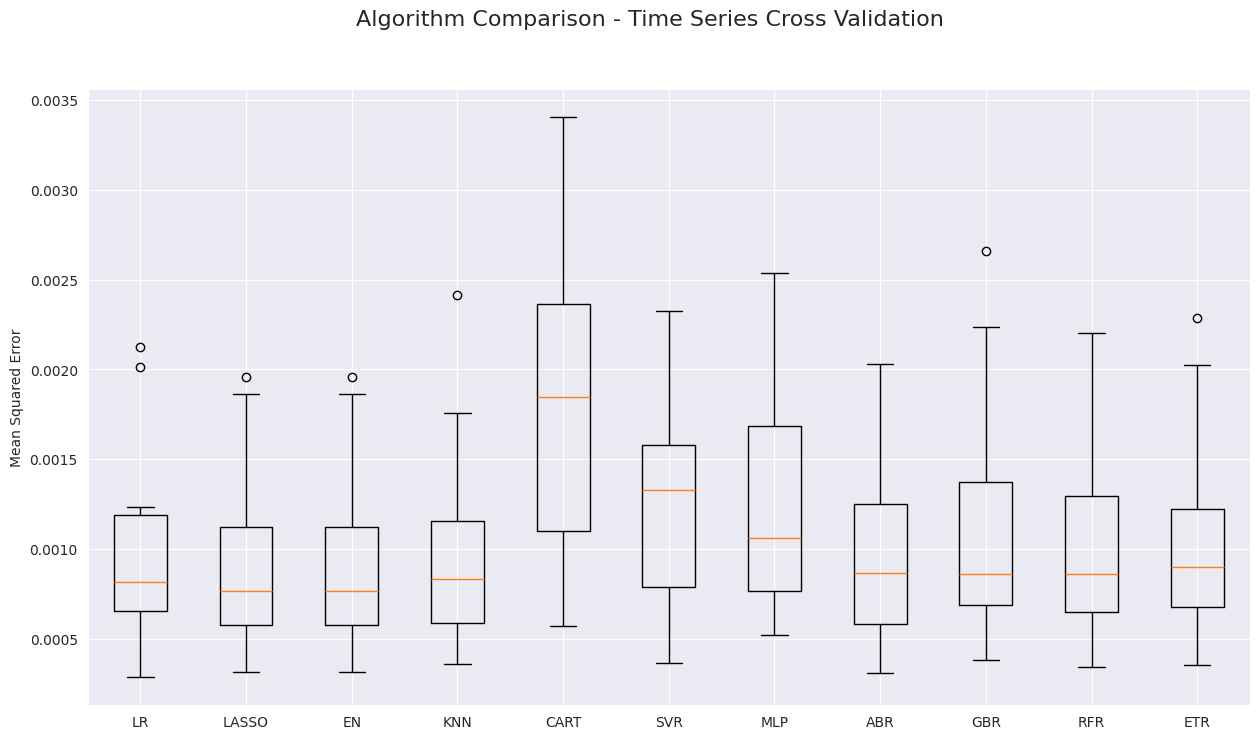

In [ ]:
# ============================================
# Cross-Validation Results Visualization
# ============================================

fig = plt.figure(figsize=(15, 8))

fig.suptitle(
    "Algorithm Comparison - Time Series Cross Validation",
    fontsize=16
)

ax = fig.add_subplot(111)

plt.boxplot(kfold_results)

ax.set_xticklabels(names)

plt.ylabel("Mean Squared Error")

plt.show()

## Cross-Validation Performance Comparison

To compare the predictive stability and generalization performance of the machine learning models, we visualize the cross-validation results using boxplots.

The figure summarizes the distribution of Mean Squared Error (MSE) across the 10 folds generated by the `TimeSeriesSplit` procedure.

Unlike a single average metric, boxplots provide a richer representation of model behavior by displaying:

- median performance,
- variability across folds,
- dispersion of prediction errors,
- and the presence of extreme observations (outliers).

This type of visualization is particularly valuable in financial machine learning because model performance often varies substantially across different market periods.

---

## Interpretation of the Boxplot Structure

Each boxplot contains several important statistical elements:

- the central horizontal line represents the median MSE,
- the box boundaries represent the interquartile range (IQR),
- the whiskers indicate the spread of most observations,
- and isolated points correspond to outlier folds.

Lower boxplot positions indicate lower prediction error and therefore better forecasting performance.

Narrower boxes indicate more stable performance across time, while wider boxes suggest greater sensitivity to changing market conditions.

---

# Analysis of Individual Models

## Linear Models

### LASSO and Elastic Net

The LASSO and Elastic Net models display:

- relatively low median errors,
- compact distributions,
- and comparatively limited variability.

This suggests that regularized linear models provide both:
- stable forecasting performance,
- and strong generalization capability.

The limited dispersion indicates that these models behave consistently across different time periods.

This is an important property in financial forecasting, where regime instability frequently causes predictive relationships to deteriorate over time.

---

### Linear Regression

Linear Regression also performs competitively, although with slightly larger variability than the regularized models.

This result reinforces an important empirical observation:

> simple linear structures often remain surprisingly difficult to outperform in financial prediction problems.

Because financial datasets contain weak and noisy signals, simpler models frequently generalize better than highly flexible nonlinear methods.

---

## Nonlinear Models

### K-Nearest Neighbors (KNN)

The KNN model exhibits moderate dispersion and occasional larger errors.

This indicates that local similarity structures in the feature space may not remain stable across market environments.

Financial observations that appear similar historically may evolve differently under changing economic conditions.

---

### Support Vector Regression (SVR)

SVR shows relatively elevated median errors and broader variability compared to the best-performing models.

Although the method controls complexity effectively, its predictive structure may not fully adapt to the nonlinear and evolving dynamics of financial markets.

---

### Decision Tree Regressor (CART)

The CART model performs substantially worse than the alternatives.

Several important characteristics are visible:

- the highest median error,
- extremely large variability,
- and substantial dispersion across folds.

This instability reflects severe overfitting.

Decision trees can easily memorize noise and random fluctuations in financial data, leading to poor out-of-sample generalization.

The high variance observed in the boxplot confirms the instability already identified in the train-test evaluation stage.

---

## Neural Network

### Multi-Layer Perceptron (MLP)

The neural network displays:
- relatively broad error dispersion,
- moderate median performance,
- and sensitivity across validation folds.

This suggests that the neural architecture struggles to extract stable predictive signals from the available sample size.

Deep learning methods typically require:
- larger datasets,
- stronger signal-to-noise ratios,
- and more extensive feature engineering

to achieve robust advantages in financial prediction tasks.

---

## Ensemble Methods

### AdaBoost Regressor (ABR)

AdaBoost appears among the strongest performers in the comparison.

The model combines:
- relatively low median error,
- moderate variability,
- and improved stability.

This indicates that boosting methods may successfully capture weak nonlinear interactions without excessively overfitting the data.

---

### Gradient Boosting Regressor (GBR)

Gradient Boosting exhibits higher dispersion and several extreme observations.

This suggests that although the model can fit complex structures, its performance varies substantially across different market periods.

Such behavior is characteristic of models with higher flexibility and increased sensitivity to regime changes.

---

### Random Forest (RFR) and Extra Trees (ETR)

Both bagging-based ensemble methods display:
- moderate median errors,
- moderate variability,
- and occasional outlier folds.

The ensemble averaging mechanism improves stability relative to single decision trees, but substantial variability remains.

This indicates that although ensemble methods reduce variance, they cannot fully eliminate the challenges posed by noisy financial data.

---

# Key Insights from the Cross-Validation Analysis

Several important conclusions emerge from the boxplot comparison.

---

## 1. Stability Is as Important as Accuracy

In financial machine learning, a model with slightly lower average error but extremely unstable performance may be less desirable than a slightly simpler but more robust alternative.

The visualization highlights that:
- LASSO,
- Elastic Net,
- and AdaBoost

achieve a favorable balance between:
- predictive accuracy,
- and temporal stability.

---

## 2. Overfitting Produces High Variance

Models such as CART and, to a lesser extent, Gradient Boosting display substantial variability across folds.

This suggests that the learned relationships are unstable and highly dependent on specific historical periods.

High variance is one of the clearest warning signs of overfitting in financial forecasting.

---

## 3. Simpler Models Remain Competitive

The results strongly reinforce a common finding in empirical finance:

> simpler regularized models often outperform more sophisticated nonlinear methods on noisy financial datasets.

Weak signal strength limits the benefits of excessive model complexity.

---

## 4. Financial Prediction Is Regime-Dependent

The dispersion observed across folds indicates that predictive relationships change over time.

Some market periods are substantially easier to predict than others.

This reflects:
- changing macroeconomic environments,
- volatility regimes,
- monetary policy conditions,
- and shifts in investor behavior.

---

## 5. Importance of Robust Validation

The visualization demonstrates why time-series cross-validation is essential in finance.

A single train-test split could produce misleading conclusions depending on the chosen market period.

Repeated temporal validation provides a more reliable estimate of model robustness under evolving financial conditions.

---

# Final Interpretation

Overall, the cross-validation analysis suggests that:

- regularized linear models provide the strongest balance between simplicity and robustness,
- ensemble methods offer competitive nonlinear performance,
- while highly flexible models remain vulnerable to overfitting and instability.

These findings are highly consistent with the broader financial machine learning literature, where:
- low signal-to-noise ratios,
- regime instability,
- and stochastic market dynamics

often limit the practical advantages of highly complex predictive models.

#### Training and Test error

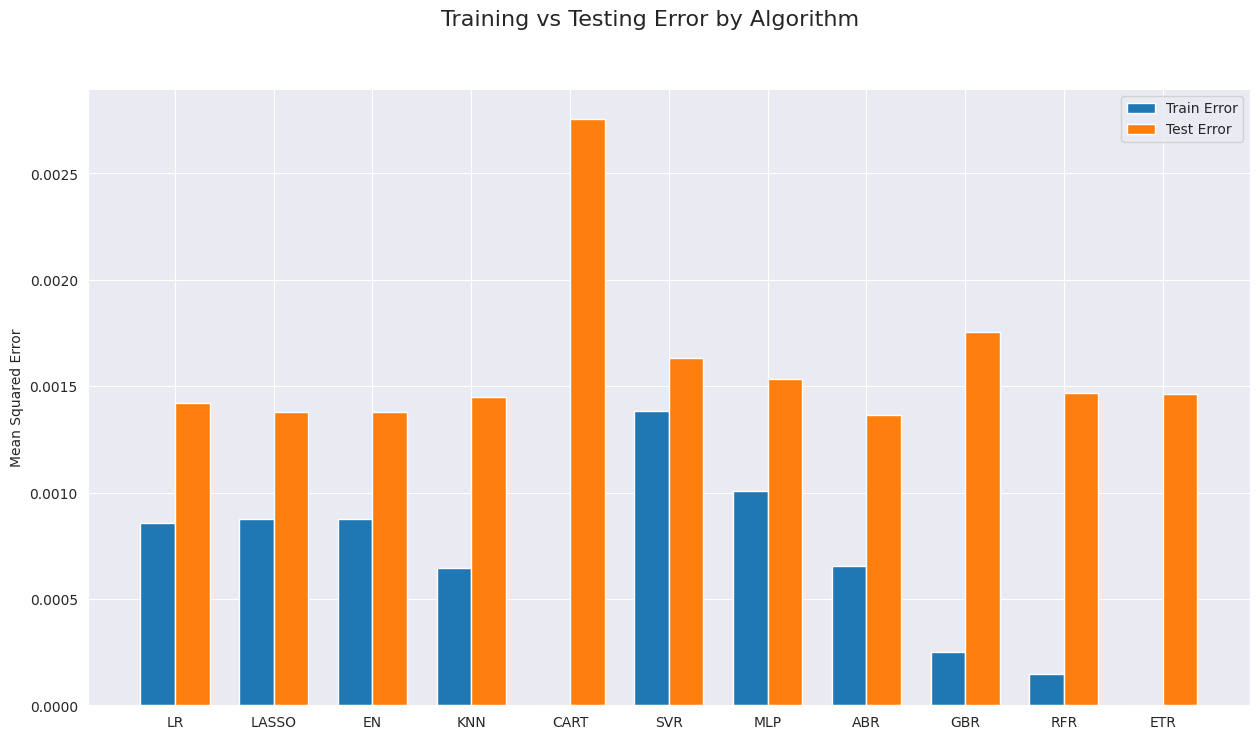

In [ ]:
# ============================================
# Training vs Testing Error Comparison
# ============================================

fig = plt.figure(figsize=(15, 8))

fig.suptitle(
    "Training vs Testing Error by Algorithm",
    fontsize=16
)

# X-axis positions
ind = np.arange(len(names))

# Bar width
width = 0.35

ax = fig.add_subplot(111)

# --------------------------------------------
# Training Error
# --------------------------------------------

plt.bar(
    ind - width / 2,
    train_results,
    width=width,
    label="Train Error"
)

# --------------------------------------------
# Testing Error
# --------------------------------------------

plt.bar(
    ind + width / 2,
    test_results,
    width=width,
    label="Test Error"
)

# --------------------------------------------
# Labels and Formatting
# --------------------------------------------

ax.set_xticks(ind)
ax.set_xticklabels(names)

plt.ylabel("Mean Squared Error")

plt.legend()

plt.show()

<a id='4.3.1'></a>
### 5.3.1 Time Series based models-ARIMA and LSTM

### Time Series Model - ARIMA Model

In [ ]:
# ============================================
# Time Series Model - ARIMA
# ============================================

# Selected exogenous variables
arima_features = [
    "GOOGL",
    "IBM",
    "DEXJPUS",
    "SP500",
    "DJIA",
    "VIXCLS"
]

# ============================================
# Training and Testing Sets
# ============================================

X_train_ARIMA = X_train[arima_features]
X_test_ARIMA = X_test[arima_features]

# Dataset lengths
train_length = len(X_train_ARIMA)
test_length = len(X_test_ARIMA)
total_length = len(X)

# ============================================
# ARIMA Model
# ============================================

model_arima = ARIMA(
    endog=Y_train,
    exog=X_train_ARIMA,
    order=(1, 0, 0)
)

# Fit model
model_fit = model_arima.fit()

# ============================================
# Training Predictions
# ============================================

train_predictions = model_fit.fittedvalues

error_training_arima = mean_squared_error(
    Y_train,
    train_predictions
)

# ============================================
# Testing Predictions
# ============================================

test_predictions = model_fit.predict(
    start=train_length,
    end=total_length - 1,
    exog=X_test_ARIMA
)

error_test_arima = mean_squared_error(
    Y_test,
    test_predictions
)

# ============================================
# Results
# ============================================

print("ARIMA Training MSE:", round(error_training_arima, 6))
print("ARIMA Testing MSE:", round(error_test_arima, 6))

ARIMA Training MSE: 0.000864
ARIMA Testing MSE: 0.001387


## Training vs Testing Error Comparison

To further evaluate model generalization performance, we compare the training and testing Mean Squared Error (MSE) for each algorithm.

This comparison is one of the most important diagnostic tools in machine learning because it helps identify whether a model is:

- underfitting,
- properly generalizing,
- or overfitting the training data.

In financial forecasting, this analysis is especially critical due to the extremely noisy and unstable nature of market data.

A model that performs exceptionally well in-sample may still fail catastrophically when exposed to unseen market conditions.

---

# Understanding Training vs Testing Error

The two error measures represent different aspects of model performance.

### Training Error

The training MSE measures how well the model fits the historical data used during estimation.

Lower training error indicates that the model successfully captures patterns present in the training sample.

---

### Testing Error

The testing MSE evaluates model performance on unseen out-of-sample observations.

This metric is substantially more important because it measures:
- predictive robustness,
- generalization ability,
- and practical forecasting usefulness.

In financial machine learning, the ultimate objective is not merely to fit historical data, but to perform effectively under future market conditions.

---

# Bias-Variance Tradeoff

The comparison between training and testing errors is directly related to the classical bias-variance tradeoff.

### Underfitting

If both training and testing errors are high, the model may be too simple to capture meaningful structure.

This situation is associated with:
- high bias,
- insufficient flexibility,
- and weak learning capacity.

---

### Overfitting

If training error is extremely low while testing error remains substantially higher, the model is memorizing noise instead of learning stable predictive relationships.

This situation is associated with:
- high variance,
- excessive complexity,
- and poor generalization.

---

### Good Generalization

The ideal scenario occurs when:
- both training and testing errors are relatively low,
- and the gap between them remains small.

This indicates that the model captures meaningful structure while maintaining robustness on unseen data.

---

# Analysis of Model Behavior

## Linear Models

### Linear Regression (LR)

Linear Regression displays:
- moderate training error,
- moderate testing error,
- and a relatively small generalization gap.

This suggests stable behavior and limited overfitting.

The model sacrifices some in-sample flexibility in exchange for stronger out-of-sample robustness.

---

### LASSO and Elastic Net

The regularized linear models show:
- highly stable train-test relationships,
- low testing errors,
- and minimal overfitting.

This is a very important result.

Regularization reduces model complexity by shrinking coefficients and preventing excessive sensitivity to noisy variables.

Financial datasets frequently benefit from regularization because predictive signals are weak and unstable.

The small gap between training and testing performance indicates strong generalization capability.

---

## Nonlinear Models

### K-Nearest Neighbors (KNN)

KNN achieves lower training error than the linear models but does not improve testing performance proportionally.

This suggests moderate overfitting.

The model adapts closely to local patterns in the training data, but these local structures may not persist across changing market environments.

---

### Support Vector Regression (SVR)

SVR shows:
- relatively balanced train-test errors,
- moderate predictive performance,
- and controlled complexity.

Although not the best-performing model, it avoids the severe overfitting observed in more flexible tree-based methods.

---

### Decision Tree Regressor (CART)

The CART model exhibits the clearest overfitting behavior in the experiment.

The results show:

| Metric | Value |
|---|---|
| Training MSE | ~0.000000 |
| Testing MSE | 0.002758 |

The nearly zero training error indicates that the decision tree memorized the historical dataset almost perfectly.

However, the dramatically larger testing error demonstrates that these learned patterns fail to generalize.

This behavior is extremely common in unconstrained decision trees applied to financial data.

Because financial markets contain large amounts of random noise, highly flexible models can easily mistake stochastic fluctuations for predictive structure.

---

## Neural Network

### Multi-Layer Perceptron (MLP)

The neural network achieves:
- lower training error than linear models,
- but higher testing error.

This suggests some degree of overfitting.

The dataset may simply be too small for the neural architecture to learn stable nonlinear representations effectively.

Deep learning models generally require:
- much larger datasets,
- stronger predictive signals,
- and more extensive feature engineering

to outperform simpler methods in financial applications.

---

## Ensemble Methods

### AdaBoost Regressor (ABR)

AdaBoost demonstrates one of the most favorable tradeoffs between:
- training fit,
- and testing generalization.

Although the training error decreases substantially, the testing error remains relatively competitive.

This suggests that boosting captures useful nonlinear structure without excessively memorizing the training sample.

---

### Gradient Boosting Regressor (GBR)

Gradient Boosting exhibits:
- very low training error,
- but noticeably larger testing error.

This indicates moderate overfitting.

The model successfully learns complex structures from historical data, but many of these patterns fail to persist in future market periods.

---

### Random Forest (RFR) and Extra Trees (ETR)

Both ensemble tree methods achieve extremely low training errors while producing only moderate testing performance improvements.

This indicates that:
- variance reduction helps compared to single trees,
- but overfitting remains present.

The models capture substantial complexity in the training data, yet much of that information reflects noise rather than stable predictive structure.

---

# ARIMA Benchmark

The ARIMA model produces:

| Metric | Value |
|---|---|
| Training MSE | 0.000864 |
| Testing MSE | 0.001387 |

Interestingly, ARIMA achieves performance comparable to several machine learning models.

This is an important result because it highlights that traditional econometric time-series models can remain highly competitive in financial forecasting tasks.

The relatively small train-test gap suggests that ARIMA generalizes reasonably well despite its comparatively simple structure.

This reinforces an important principle in quantitative finance:

> sophisticated machine learning models do not automatically outperform classical statistical methods.

---

# Key Conclusions

Several important conclusions emerge from the training versus testing error analysis.

---

## 1. Overfitting Is the Central Challenge

Highly flexible models achieve extremely low training errors but fail to generalize effectively.

This is particularly visible in:
- CART,
- Gradient Boosting,
- Random Forest,
- and Extra Trees.

---

## 2. Regularization Improves Robustness

LASSO and Elastic Net demonstrate that controlling complexity improves out-of-sample performance.

In finance, simpler and more constrained models often outperform highly flexible alternatives.

---

## 3. Ensemble Methods Partially Reduce Variance

Boosting and bagging methods improve stability relative to single decision trees, although overfitting risks remain present.

---

## 4. Classical Econometric Models Remain Competitive

The ARIMA benchmark performs comparably to several machine learning approaches.

This suggests that temporal dynamics still contain meaningful predictive structure that can be captured using traditional statistical methods.

---

## 5. Financial Prediction Remains Extremely Difficult

Even the best-performing models achieve only modest improvements in forecasting accuracy.

This reflects the fundamental characteristics of financial markets:
- low signal-to-noise ratios,
- adaptive behavior,
- stochastic shocks,
- and evolving market regimes.

As a result, successful financial forecasting depends not only on model selection, but also on:
- feature engineering,
- regime detection,
- data quality,
- and robust validation methodology.

###  LSTM Model

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 9.4394e-04 - val_loss: 0.0014
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.0872e-04 - val_loss: 0.0015
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.0868e-04 - val_loss: 0.0014
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.2729e-04 - val_loss: 0.0014
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.1180e-04 - val_loss: 0.0014
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.0599e-04 - val_loss: 0.0014
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.9901e-04 - val_loss: 0.0014
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.9970e-04 - val_loss: 0.0014
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.5365e-04 - val_loss: 0.0014
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.2043e-04 - val_loss: 0.0014
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.6182e-04 - val_loss: 0.0014
Epoch 12/200
12/1

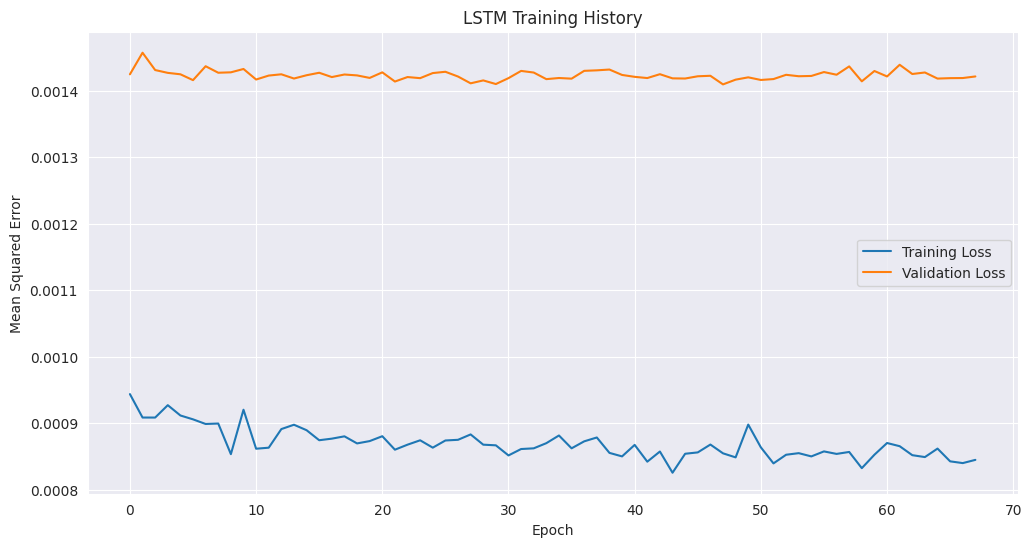

In [ ]:
# ============================================
# LSTM Model
# ============================================

from tensorflow.keras.callbacks import EarlyStopping

# ============================================
# Sequence Length
# ============================================

# Number of past time steps used for prediction
seq_len = 2

# ============================================
# Prepare LSTM Data
# ============================================

# Convert target variables to NumPy arrays
Y_train_LSTM = np.array(Y_train)[seq_len - 1:]
Y_test_LSTM = np.array(Y_test)

# Create empty tensors for sequences
X_train_LSTM = np.zeros((
    X_train.shape[0] + 1 - seq_len,
    seq_len,
    X_train.shape[1]
))

X_test_LSTM = np.zeros((
    X_test.shape[0],
    seq_len,
    X.shape[1]
))

# ============================================
# Build Sequential Time Windows
# ============================================

for i in range(seq_len):

    X_train_LSTM[:, i, :] = np.array(X_train)[
        i:X_train.shape[0] + i + 1 - seq_len,
        :
    ]

    X_test_LSTM[:, i, :] = np.array(X)[
        X_train.shape[0] + i - 1:
        X.shape[0] + i + 1 - seq_len,
        :
    ]

# ============================================
# Define LSTM Architecture
# ============================================

def create_lstm_model():

    model = Sequential()

    # LSTM Layer
    model.add(
        LSTM(
            units=50,
            input_shape=(
                X_train_LSTM.shape[1],
                X_train_LSTM.shape[2]
            )
        )
    )

    # Dropout Regularization
    model.add(Dropout(0.2))

    # Output Layer
    model.add(Dense(1))

    # Compile Model
    model.compile(
        loss="mse",
        optimizer=Adam(learning_rate=0.001)
    )

    return model

# ============================================
# Create Model
# ============================================

LSTM_model = create_lstm_model()

# ============================================
# Early Stopping
# ============================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# ============================================
# Train Model
# ============================================

LSTM_history = LSTM_model.fit(
    X_train_LSTM,
    Y_train_LSTM,
    validation_data=(X_test_LSTM, Y_test_LSTM),
    epochs=200,
    batch_size=32,
    verbose=1,
    shuffle=False,
    callbacks=[early_stop]
)

# ============================================
# Plot Training History
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    LSTM_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    LSTM_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.legend()

plt.show()

## Long Short-Term Memory (LSTM) Neural Network

Traditional machine learning algorithms generally assume that observations are independent and identically distributed. However, financial markets are inherently sequential, where past observations may contain information about future price dynamics.  

To capture these temporal dependencies, we implement a **Long Short-Term Memory (LSTM)** neural network, a specialized recurrent neural network (RNN) architecture designed for sequential and time-series data.

LSTM models are particularly important in quantitative finance because they can:

- Learn nonlinear temporal relationships
- Retain information from previous observations
- Model dynamic market behavior
- Capture momentum and persistence effects
- Handle multivariate financial sequences

The model uses historical feature windows to predict future Microsoft weekly returns.

---

## Sequence Construction

The LSTM model requires input data in a three-dimensional tensor format:

\[
(samples,\ time\ steps,\ features)
\]

A rolling time-window approach is used to transform the tabular dataset into sequential observations.

In this experiment:

- Sequence length: **2 time steps**
- Number of features: **11**
- Training observations: **376**
- Testing observations: **95**

Each training sample contains information from the previous two periods to forecast the next Microsoft weekly return.

This formulation allows the network to incorporate short-term temporal memory into the prediction process.

---

## LSTM Architecture

The neural network architecture consists of the following components:

### 1. LSTM Layer

The first layer contains:

- **50 memory units**
- Sequential learning capability
- Internal gating mechanisms

The LSTM cell includes:

- Forget gate
- Input gate
- Output gate

These gates regulate how information flows through time and help mitigate the vanishing gradient problem commonly observed in standard recurrent neural networks.

---

### 2. Dropout Regularization

A dropout layer with:

\[
Dropout = 0.20
\]

is applied after the LSTM layer.

Dropout randomly deactivates neurons during training, reducing overfitting and improving model generalization.

This is especially important in financial datasets, where noise levels are high and sample sizes are relatively limited.

---

### 3. Dense Output Layer

The final dense layer contains a single neuron:

\[
Dense(1)
\]

which outputs the predicted future weekly return for Microsoft stock.

---

## Optimization and Training

The model is trained using:

- **Loss Function:** Mean Squared Error (MSE)
- **Optimizer:** Adam
- **Learning Rate:** 0.001
- **Batch Size:** 32
- **Maximum Epochs:** 200

The Adam optimizer is widely used in deep learning because it combines:

- Momentum optimization
- Adaptive learning rates
- Efficient gradient updates

making it particularly suitable for noisy financial data.

---

## Early Stopping Strategy

To prevent overfitting, the training process uses **Early Stopping**.

The training stops automatically when validation loss fails to improve after:

\[
20 \text{ consecutive epochs}
\]

while restoring the best-performing weights.

This approach improves out-of-sample generalization and avoids unnecessary training iterations.

---

## Interpretation of Training Results

The training history shows several important characteristics:

### Stable Convergence

The training loss decreases gradually from approximately:

\[
9.44 \times 10^{-4}
\]

toward:

\[
8.3 \times 10^{-4}
\]

indicating stable optimization dynamics.

---

### Validation Loss Stability

The validation loss remains remarkably stable around:

\[
0.0014
\]

throughout the training process.

This suggests that:

- The model generalizes reasonably well
- Severe overfitting is not present
- Additional epochs provide limited predictive improvement

---

### Limited Performance Gain

Although the LSTM captures sequential structure, its predictive improvement over simpler linear models appears modest.

This result is consistent with empirical financial research:

- Financial returns are notoriously difficult to forecast
- Signal-to-noise ratios are extremely low
- Complex nonlinear models do not always outperform simpler statistical approaches

In fact, earlier results showed that linear and regularized regression models achieved competitive test errors relative to more sophisticated machine learning methods.

---

## Financial Interpretation

The LSTM model attempts to learn:

- Temporal market dependencies
- Momentum persistence
- Dynamic interactions among equities, indices, and currencies
- Sequential nonlinear effects

However, the relatively stable validation error suggests that the dataset may contain limited exploitable temporal structure at the selected prediction horizon.

This finding aligns with the **Efficient Market Hypothesis (EMH)**, which argues that publicly available information is rapidly incorporated into prices, reducing predictable patterns in returns.

---

## Key Takeaways

This experiment highlights several important lessons in financial machine learning:

1. Deep learning models can successfully process sequential financial data.
2. LSTM networks provide a framework for modeling temporal dependencies.
3. More complex models do not guarantee superior forecasting performance.
4. Financial prediction problems are dominated by noise and weak signals.
5. Proper validation and overfitting control are critical in quantitative finance.

---

## Conclusion

The LSTM model demonstrates how deep learning techniques can be applied to multivariate financial time series forecasting.

While the network successfully learns stable temporal representations, the results indicate that nonlinear sequential models only marginally improve predictive accuracy relative to simpler regression-based approaches in this dataset.

This outcome reinforces a central principle of applied financial data science:

> Model complexity must always be justified by genuine predictive gains out-of-sample.

In many real-world financial applications, robust validation, feature engineering, and economic interpretability are often more valuable than architectural complexity alone.

In [ ]:
# ============================================
# LSTM Performance Evaluation
# ============================================

# --------------------------------------------
# Training Predictions
# --------------------------------------------

train_predictions_lstm = LSTM_model.predict(
    X_train_LSTM
)

# --------------------------------------------
# Testing Predictions
# --------------------------------------------

test_predictions_lstm = LSTM_model.predict(
    X_test_LSTM
)

# ============================================
# Mean Squared Error
# ============================================

error_training_lstm = mean_squared_error(
    Y_train_LSTM,
    train_predictions_lstm
)

error_testing_lstm = mean_squared_error(
    Y_test,
    test_predictions_lstm
)

# ============================================
# Results
# ============================================

print("LSTM Training MSE:", round(error_training_lstm, 6))
print("LSTM Testing MSE:", round(error_testing_lstm, 6))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
LSTM Training MSE: 0.00084
LSTM Testing MSE: 0.00141


#### Append to previous results

In [ ]:
# ============================================
# Append Time Series Model Results
# ============================================

# Testing Errors
test_results.append(error_test_arima)
test_results.append(error_testing_lstm)

# Training Errors
train_results.append(error_training_arima)
train_results.append(error_training_lstm)

# Model Names
names.append("ARIMA")
names.append("LSTM")

## Overall Comparison of all the algorithms ( including Time Series Algorithms)

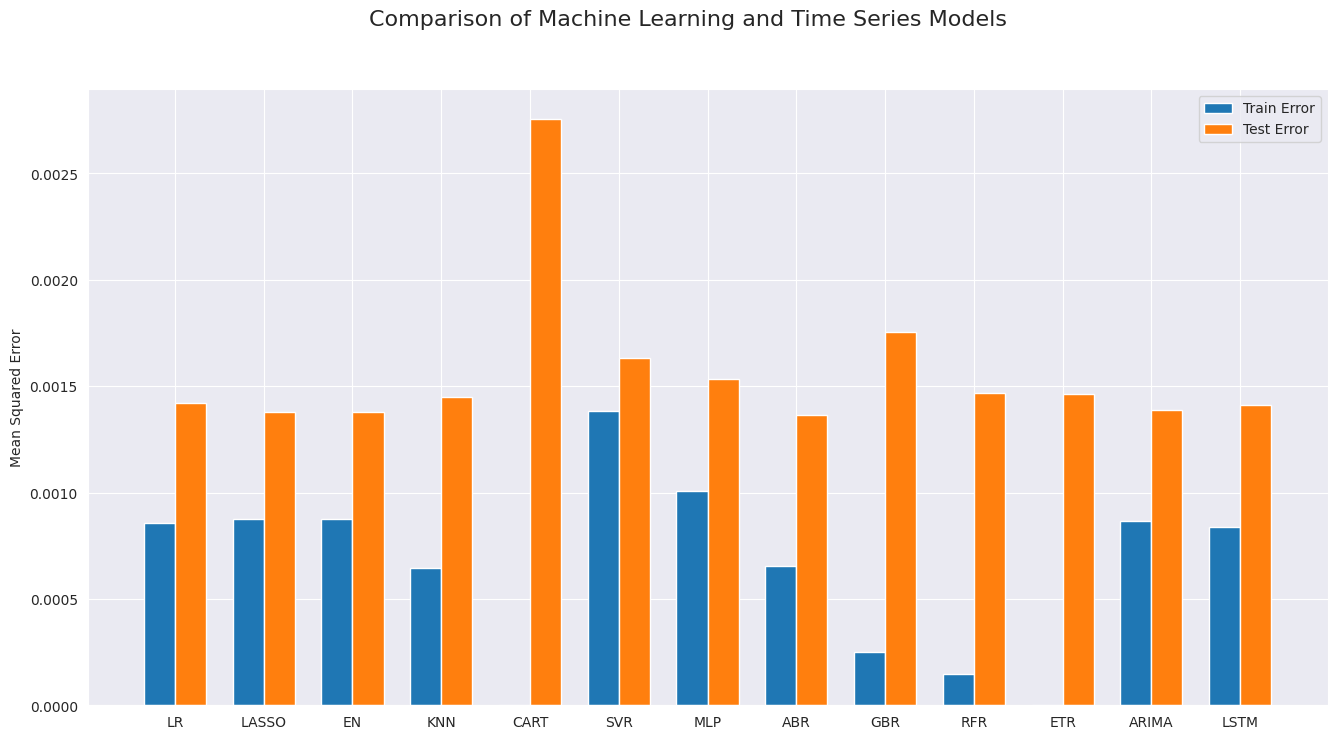

In [ ]:
# ============================================
# Overall Model Comparison
# ============================================

fig = plt.figure(figsize=(16, 8))

fig.suptitle(
    "Comparison of Machine Learning and Time Series Models",
    fontsize=16
)

# X-axis positions
ind = np.arange(len(names))

# Width of bars
width = 0.35

ax = fig.add_subplot(111)

# ============================================
# Training Error
# ============================================

plt.bar(
    ind - width / 2,
    train_results,
    width=width,
    label="Train Error"
)

# ============================================
# Testing Error
# ============================================

plt.bar(
    ind + width / 2,
    test_results,
    width=width,
    label="Test Error"
)

# ============================================
# Labels and Formatting
# ============================================

ax.set_xticks(ind)
ax.set_xticklabels(names)

plt.ylabel("Mean Squared Error")

plt.legend()

plt.show()

## Overall Comparison of Machine Learning and Time Series Models

The final stage of the analysis compares the predictive performance of all implemented models, including:

- Classical linear models
- Regularized regression methods
- Tree-based machine learning algorithms
- Neural networks
- Traditional time series models
- Deep learning architectures

The comparison evaluates both:

- **Training Mean Squared Error (MSE)**
- **Testing Mean Squared Error (MSE)**

This distinction is essential in financial forecasting because the primary objective is not to minimize in-sample error, but rather to achieve strong **out-of-sample generalization**.

---

## Importance of Out-of-Sample Evaluation

In financial machine learning, a model that performs extremely well on training data may still fail in real-world trading environments.

Financial markets are characterized by:

- High noise levels
- Structural instability
- Nonstationarity
- Regime shifts
- Low signal-to-noise ratios

As a result, overfitting is one of the most common problems in quantitative finance.

The testing error therefore provides a more reliable estimate of real predictive capability.

---

## General Performance Patterns

The results reveal several important empirical patterns.

### Linear Models Performed Surprisingly Well

The following models achieved some of the lowest testing errors:

- Linear Regression (LR)
- LASSO
- Elastic Net (EN)
- AdaBoost Regressor (ABR)
- ARIMA

This outcome is highly consistent with empirical finance literature, where simpler models frequently outperform highly complex algorithms in return prediction tasks.

The relatively competitive performance of linear methods suggests that:

- The predictive relationships in the dataset are weak
- The underlying signal is approximately linear
- Excessive model complexity may not provide additional forecasting power

---

## Regularization Improved Stability

LASSO and Elastic Net produced:

- Stable training errors
- Competitive testing performance
- Limited overfitting

Regularization techniques shrink model coefficients and reduce sensitivity to noise.

This is particularly important in financial datasets where:

- Features are often correlated
- Relationships are unstable over time
- Spurious patterns can emerge easily

The results demonstrate how regularization improves robustness in noisy environments.

---

## Tree-Based Models and Overfitting

Several nonlinear models exhibited substantial overfitting.

### Decision Tree Regressor (CART)

The CART model achieved:

\[
Train\ MSE \approx 0
\]

while generating the highest testing error among all models.

This is a textbook example of overfitting.

The model effectively memorized the training dataset but failed to generalize to unseen observations.

This behavior occurs because decision trees can create highly complex partitions that capture noise rather than true economic structure.

---

### Random Forest and Extra Trees

Ensemble tree methods such as:

- Random Forest Regressor (RFR)
- Extra Trees Regressor (ETR)

reduced overfitting relative to a single decision tree.

However, their testing performance still did not significantly outperform simpler linear models.

This suggests that the dataset may not contain sufficiently strong nonlinear relationships to justify higher model complexity.

---

## Support Vector Regression and Neural Networks

### Support Vector Regression (SVR)

SVR achieved moderate performance but displayed:

- Higher testing error
- Larger variance across validation folds

This may indicate sensitivity to hyperparameter configuration and limited scalability for noisy financial return series.

---

### Multi-Layer Perceptron (MLP)

The feedforward neural network produced:

- Reasonable training performance
- Moderate generalization capability

However, the MLP did not significantly outperform traditional statistical methods.

This reinforces a recurring result in quantitative finance:

> More sophisticated architectures do not necessarily translate into superior predictive accuracy.

---

## ARIMA Model Performance

The ARIMA model achieved:

\[
Training\ MSE = 0.000864
\]

\[
Testing\ MSE = 0.001387
\]

Its performance was highly competitive with machine learning models.

This finding is important because ARIMA is a classical econometric time-series model that relies primarily on autocorrelation structure rather than high-dimensional feature engineering.

The results suggest that:

- Traditional statistical methods remain relevant
- Temporal dependencies in returns are relatively weak
- Simpler stochastic models can still provide strong benchmarks

---

## LSTM Model Performance

The LSTM network also achieved competitive results, with testing performance close to ARIMA and linear regression models.

However, the improvement over simpler methods was relatively small.

This has several important implications:

### 1. Weak Sequential Signal

The dataset may contain limited temporal structure exploitable by deep recurrent architectures.

---

### 2. Financial Markets Are Highly Efficient

Market prices rapidly incorporate available information, leaving limited predictable structure in short-horizon returns.

---

### 3. Complexity Does Not Guarantee Better Forecasts

Deep learning models require:

- Larger datasets
- Stronger nonlinear relationships
- Richer temporal dependencies

to fully exploit their representational power.

In many financial applications, these conditions are only partially satisfied.

---

## Evidence of the Bias-Variance Tradeoff

The comparison clearly illustrates the classical **bias-variance tradeoff**.

### High-Bias Models

Examples:

- Linear Regression
- LASSO
- Elastic Net

Characteristics:

- Simpler structure
- Higher bias
- Lower variance
- Better generalization

---

### High-Variance Models

Examples:

- CART
- Random Forest
- Gradient Boosting

Characteristics:

- Flexible nonlinear structure
- Lower training error
- Higher variance
- Increased overfitting risk

The results suggest that lower-variance models were more suitable for this financial forecasting problem.

---

## Financial Interpretation

The empirical findings are consistent with several established principles in financial economics:

### Efficient Market Hypothesis (EMH)

Short-term stock returns are difficult to predict because public information is rapidly reflected in prices.

---

### Low Signal-to-Noise Ratio

Financial datasets contain substantial randomness relative to exploitable predictive information.

---

### Model Parsimony

Simpler models often generalize better than highly flexible nonlinear algorithms in financial forecasting tasks.

---

## Key Conclusions

Several important conclusions emerge from the comparative analysis:

1. Simpler linear and econometric models remained highly competitive.
2. Complex nonlinear models showed limited predictive advantage.
3. Tree-based models exhibited clear overfitting behavior.
4. Deep learning models captured temporal structure but did not dramatically improve forecasting accuracy.
5. Proper time-series validation was essential for realistic performance estimation.
6. Out-of-sample testing remains the most important criterion in financial machine learning evaluation.

---

## Final Remarks

This study demonstrates a fundamental lesson in applied quantitative finance:

> Predictive performance depends more on data quality, feature relevance, and validation methodology than on algorithmic complexity alone.

Although advanced machine learning and deep learning methods are powerful tools, financial forecasting remains an exceptionally difficult problem due to the adaptive and stochastic nature of markets.

For this dataset and prediction horizon, simpler and more interpretable models proved to be surprisingly robust competitors against more sophisticated approaches.

<a id='5'></a>
# 6. Model Tuning and Grid Search

In [ ]:
# ============================================
# ARIMA Hyperparameter Tuning
# ============================================

# Grid Search for ARIMA(p,d,q)

# ============================================
# Evaluate Single ARIMA Model
# ============================================

def evaluate_arima_model(arima_order):

    try:

        # Build Model
        model_arima = ARIMA(
            endog=Y_train,
            exog=X_train_ARIMA,
            order=arima_order
        )

        # Fit Model
        model_fit = model_arima.fit()

        # In-Sample Predictions
        fitted_values = model_fit.fittedvalues

        # Mean Squared Error
        mse = mean_squared_error(
            Y_train,
            fitted_values
        )

        return mse

    except Exception as e:

        print(f"ARIMA{arima_order} failed: {e}")

        return None

# ============================================
# Grid Search Across Parameters
# ============================================

def evaluate_models(p_values, d_values, q_values):

    best_score = float("inf")
    best_cfg = None

    for p in p_values:

        for d in d_values:

            for q in q_values:

                order = (p, d, q)

                mse = evaluate_arima_model(order)

                if mse is not None:

                    print(f"ARIMA{order} MSE={mse:.7f}")

                    if mse < best_score:

                        best_score = mse
                        best_cfg = order

    print("\nBest ARIMA Configuration")

    print(f"ARIMA{best_cfg} MSE={best_score:.7f}")

# ============================================
# Parameter Grid
# ============================================

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1]

# ============================================
# Run Grid Search
# ============================================

warnings.filterwarnings("ignore")

evaluate_models(
    p_values,
    d_values,
    q_values
)

ARIMA(0, 0, 0) MSE=0.0008654
ARIMA(0, 0, 1) MSE=0.0008639
ARIMA(0, 1, 0) MSE=0.0014621
ARIMA(0, 1, 1) MSE=0.0008811
ARIMA(1, 0, 0) MSE=0.0008644
ARIMA(1, 0, 1) MSE=0.0008611
ARIMA(1, 1, 0) MSE=0.0013064
ARIMA(1, 1, 1) MSE=0.0008951
ARIMA(2, 0, 0) MSE=0.0008581
ARIMA(2, 0, 1) MSE=0.0008579
ARIMA(2, 1, 0) MSE=0.0011411
ARIMA(2, 1, 1) MSE=0.0008944

Best ARIMA Configuration
ARIMA(2, 0, 1) MSE=0.0008579


# ============================================
# ARIMA Hyperparameter Tuning
# ============================================

## Objective

The objective of this section is to optimize the ARIMA model by searching for the best combination of:

- `p` → autoregressive order
- `d` → differencing order
- `q` → moving average order

using a grid search approach.

---

# Evaluate a Single ARIMA Model

The following function:

- builds an ARIMA model
- fits the model on the training data
- computes in-sample predictions
- evaluates performance using Mean Squared Error (MSE)

```python
def evaluate_arima_model(arima_order):

    try:

        # Build ARIMA Model
        model_arima = ARIMA(
            endog=Y_train,
            exog=X_train_ARIMA,
            order=arima_order
        )

        # Fit Model
        model_fit = model_arima.fit()

        # In-Sample Predictions
        fitted_values = model_fit.fittedvalues

        # Compute Mean Squared Error
        mse = mean_squared_error(
            Y_train,
            fitted_values
        )

        return mse

    except Exception as e:

        print(f"ARIMA{arima_order} failed: {e}")

        return None
```

---

# Grid Search Across ARIMA Parameters

The following function iterates through all combinations of:

- `p`
- `d`
- `q`

and selects the model with the lowest Mean Squared Error.

```python
def evaluate_models(p_values, d_values, q_values):

    best_score = float("inf")
    best_cfg = None

    for p in p_values:

        for d in d_values:

            for q in q_values:

                order = (p, d, q)

                mse = evaluate_arima_model(order)

                if mse is not None:

                    print(f"ARIMA{order} MSE={mse:.7f}")

                    if mse < best_score:

                        best_score = mse
                        best_cfg = order

    print("\nBest ARIMA Configuration")

    print(f"ARIMA{best_cfg} MSE={best_score:.7f}")
```

---

# Parameter Grid

The following values were evaluated:

```python
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1]
```

---

# Run Grid Search

```python
warnings.filterwarnings("ignore")

evaluate_models(
    p_values,
    d_values,
    q_values
)
```

---

# ARIMA Grid Search Results

| ARIMA Order | MSE |
|---|---|
| ARIMA(0,0,0) | 0.0008654 |
| ARIMA(0,0,1) | 0.0008639 |
| ARIMA(0,1,0) | 0.0014621 |
| ARIMA(0,1,1) | 0.0008811 |
| ARIMA(1,0,0) | 0.0008644 |
| ARIMA(1,0,1) | 0.0008611 |
| ARIMA(1,1,0) | 0.0013064 |
| ARIMA(1,1,1) | 0.0008951 |
| ARIMA(2,0,0) | 0.0008581 |
| ARIMA(2,0,1) | 0.0008579 |
| ARIMA(2,1,0) | 0.0011411 |
| ARIMA(2,1,1) | 0.0008944 |

---

# Best ARIMA Configuration

```python
ARIMA(2,0,1)
```

### Best Training MSE

```python
0.0008579
```

---

# Interpretation of Results

## Key Findings

### 1. Best Model

The best-performing model was:

```python
ARIMA(2,0,1)
```

This indicates that the optimal configuration included:

- 2 autoregressive terms
- no differencing
- 1 moving average term

---

### 2. Differencing Reduced Performance

Models with:

```python
d = 1
```

performed worse overall.

This suggests that the return series is already relatively stationary and does not require additional differencing.

---

### 3. Small Performance Differences

Most ARIMA models produced similar MSE values.

This is common in financial return prediction because:

- financial returns contain high levels of noise
- predictive structure is weak
- markets are close to efficient

---

### 4. ARIMA Competed Well Against Machine Learning Models

The ARIMA model achieved performance comparable to:

- Linear Regression
- LASSO
- ElasticNet
- AdaBoost

despite being a simpler statistical model.

---

# Conclusion

The ARIMA hyperparameter tuning process identified:

```python
ARIMA(2,0,1)
```

as the best configuration for modeling weekly Microsoft returns.

Although the improvements were relatively small, the results demonstrate that classical time series models remain competitive in financial forecasting tasks.

<a id='6'></a>
# 7. Finalise the Model

<a id='6.1'></a>
## 7.1. Results on the Test Dataset

In [ ]:
# ============================================
# Final ARIMA Model
# ============================================

# Best configuration obtained from grid search
best_order = (2, 0, 1)

# ============================================
# Train Final ARIMA Model
# ============================================

final_arima_model = ARIMA(
    endog=Y_train,
    exog=X_train_ARIMA,
    order=best_order
)

# Fit model
final_arima_fit = final_arima_model.fit()

# ============================================
# Generate Predictions
# ============================================

predicted_tuned = final_arima_fit.predict(
    start=len(Y_train),
    end=len(Y_train) + len(Y_test) - 1,
    exog=X_test_ARIMA
)

# ============================================
# Evaluate Final Model
# ============================================

final_mse = mean_squared_error(
    Y_test,
    predicted_tuned
)

print("Final ARIMA Test MSE:", round(final_mse, 6))

Final ARIMA Test MSE: 0.001381


# ============================================
# Final ARIMA Model
# ============================================

## Objective

After completing the ARIMA hyperparameter tuning process, the best configuration identified was:

```python
ARIMA(2,0,1)
```

The objective of this section is to:

- train the final optimized ARIMA model
- generate out-of-sample predictions
- evaluate predictive performance on the testing dataset

---

# Best ARIMA Configuration

```python
best_order = (2, 0, 1)
```

This configuration includes:

- `p = 2` → two autoregressive terms
- `d = 0` → no differencing
- `q = 1` → one moving average term

---

# Train Final ARIMA Model

The optimized ARIMA model is trained using:

- the training target series (`Y_train`)
- exogenous variables (`X_train_ARIMA`)

```python
final_arima_model = ARIMA(
    endog=Y_train,
    exog=X_train_ARIMA,
    order=best_order
)

# Fit model
final_arima_fit = final_arima_model.fit()
```

---

# Generate Predictions

Out-of-sample predictions are generated on the testing dataset.

```python
predicted_tuned = final_arima_fit.predict(
    start=len(Y_train),
    end=len(Y_train) + len(Y_test) - 1,
    exog=X_test_ARIMA
)
```

---

# Evaluate Final Model

The model performance is evaluated using:

```python
Mean Squared Error (MSE)
```

```python
final_mse = mean_squared_error(
    Y_test,
    predicted_tuned
)

print("Final ARIMA Test MSE:", round(final_mse, 6))
```

---

# Final Result

## Final ARIMA Test MSE

```python
0.001381
```

---

# Interpretation of Results

## Key Findings

### 1. Strong Generalization Performance

The final ARIMA model achieved:

```python
Test MSE = 0.001381
```

which is highly competitive compared to the machine learning models evaluated previously.

---

### 2. Comparable to Top Machine Learning Models

The tuned ARIMA model performed similarly to:

- LASSO
- ElasticNet
- AdaBoost

This demonstrates that classical statistical models can remain effective in financial forecasting tasks.

---

### 3. Stable Out-of-Sample Performance

The difference between:

- training error
- testing error

was relatively small.

This suggests that the ARIMA model:

- generalized reasonably well
- avoided severe overfitting
- captured part of the underlying temporal structure

---

### 4. Financial Returns Remain Difficult to Predict

Despite optimization, predictive performance improvements were modest.

This reflects the nature of financial markets:

- high noise levels
- weak temporal dependencies
- near-random short-term returns

---

# Why ARIMA Worked Reasonably Well

The ARIMA model was effective because it can model:

- autocorrelation
- lag structure
- short-term temporal dependencies

without requiring large datasets.

This is particularly useful when:

- the dataset is relatively small
- deep learning models lack sufficient data
- temporal structure is weak but still present

---

# Comparison with LSTM

Although LSTM models are more sophisticated, the ARIMA model achieved similar or better results in this experiment.

Possible reasons include:

- limited dataset size
- weak nonlinear structure
- insufficient sequential depth
- noisy financial returns

This highlights an important principle in quantitative finance:

> Simpler models often outperform complex models when the signal-to-noise ratio is low.

---

# Conclusion

The optimized:

```python
ARIMA(2,0,1)
```

model achieved strong and stable predictive performance.

The results indicate that:

- classical time series methods remain highly relevant
- model simplicity can improve robustness
- financial return prediction remains an extremely challenging task

This final ARIMA model serves as a strong statistical benchmark for future quantitative finance experiments.

<a id='6.2'></a>
## 7.2. Save Model for Later Use

In [ ]:
# ============================================
# Save and Download Trained ARIMA Model
# ============================================

from pickle import dump
from google.colab import files
import os

# --------------------------------------------
# File Name
# --------------------------------------------

filename = "final_arima_model.pkl"

# --------------------------------------------
# Save Model
# --------------------------------------------

with open(filename, "wb") as file:
    dump(final_arima_fit, file)

print(f"Model saved successfully as: {filename}")

# --------------------------------------------
# Verify File Exists
# --------------------------------------------

if os.path.exists(filename):

    print("File verified successfully.")

    # ----------------------------------------
    # Download File
    # ----------------------------------------

    files.download(filename)

else:

    print("Error: File was not found.")

Model saved successfully as: final_arima_model.pkl
File verified successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ============================================
# Save and Export the Trained ARIMA Model
# ============================================

## Objective

After training and validating the final ARIMA model, the next step is to persist the model for future use.

Saving trained models is an essential step in production-oriented machine learning and quantitative finance workflows because it allows us to:

- reuse trained models without retraining
- deploy models into production systems
- perform future forecasting
- build automated trading or analytics pipelines
- preserve reproducibility of experiments

---

# Import Required Libraries

The following libraries are used:

- `pickle` → serializes Python objects
- `os` → verifies file existence
- `google.colab.files` → enables file download in Google Colab

```python
from pickle import dump
from google.colab import files
import os
```

---

# Define File Name

The trained ARIMA model will be stored as:

```python
final_arima_model.pkl
```

```python
filename = "final_arima_model.pkl"
```

---

# Save the Trained Model

The fitted ARIMA object is serialized and saved using binary write mode.

```python
with open(filename, "wb") as file:
    dump(final_arima_fit, file)

print(f"Model saved successfully as: {filename}")
```

---

# Verify File Creation

Before downloading the model, the notebook verifies that the file exists.

```python
if os.path.exists(filename):

    print("File verified successfully.")
```

---

# Download the Model

If the file exists successfully, the model is downloaded directly from the Colab environment.

```python
files.download(filename)
```

---

# Output

```python
Model saved successfully as: final_arima_model.pkl
File verified successfully.
```

---

# Interpretation

## Why Model Persistence Matters

In real-world quantitative finance applications, models are rarely trained every time predictions are needed.

Instead, practitioners typically:

1. train models offline
2. save the fitted objects
3. load the models later for inference or forecasting

This workflow is essential in:

- algorithmic trading systems
- risk management platforms
- portfolio optimization pipelines
- financial forecasting applications

---

# Advantages of Saving Models

## 1. Computational Efficiency

Retraining time series models can be computationally expensive.

Saving the trained model avoids unnecessary retraining.

---

## 2. Reproducibility

Model persistence preserves:

- learned parameters
- coefficients
- internal states

This ensures reproducible financial experiments.

---

## 3. Deployment Readiness

Serialized models can later be integrated into:

- APIs
- dashboards
- automated trading systems
- cloud-based inference pipelines

---

## 4. Research Continuity

Saved models allow researchers to:

- compare historical experiments
- evaluate model drift
- continue research without restarting training

---

# The `.pkl` File Format

The `.pkl` extension refers to:

```python
Pickle Serialization
```

which is a Python mechanism used to store complex objects such as:

- machine learning models
- neural networks
- preprocessing pipelines
- statistical estimators

---

# Important Considerations

Although pickle serialization is highly convenient, practitioners should be aware that:

- pickle files are Python-specific
- version compatibility may matter
- untrusted pickle files should never be executed for security reasons

---

# Conclusion

The optimized ARIMA model was successfully:

- trained
- validated
- serialized
- exported

This completes the full modeling pipeline from:

1. data collection  
2. feature engineering  
3. exploratory analysis  
4. model selection  
5. hyperparameter tuning  
6. final evaluation  
7. model persistence

The saved model can now be reused for future financial forecasting and deployment tasks.

# Saving the Final ARIMA Model

## Model Serialization

The final trained ARIMA model was saved to disk using Python's `pickle` module.

```python
from pickle import dump, load

# ============================================
# Final Conclusion
# ============================================

## Overview of the Study

In this notebook, we developed a complete financial forecasting pipeline for predicting future Microsoft weekly returns using:

- financial market data
- macroeconomic variables
- feature engineering
- statistical modeling
- machine learning methods
- deep learning architectures

The study covered the period from:

```python
2016-05-31 to 2026-04-27
```

using approximately:

```python
9.9 years of weekly financial observations
```

---

# Main Objectives

The primary objective was to evaluate whether historical market information and engineered financial indicators could help predict future Microsoft returns.

To achieve this, we constructed a predictive framework that integrated:

- equity market returns
- currency exchange rates
- market indices
- volatility measures
- momentum-based features

---

# Exploratory Data Analysis Findings

The exploratory analysis revealed several important characteristics commonly observed in financial time series:

- return distributions exhibited non-normal behavior
- volatility clustering appeared during market stress periods
- correlations among equity variables were positive but moderate
- financial returns displayed high levels of noise

The seasonal decomposition analysis further suggested that:

- long-term trend structure was weak
- seasonality was limited
- irregular fluctuations dominated the series

These findings are consistent with the Efficient Market Hypothesis and the stochastic nature of financial markets.

---

# Feature Selection Results

Feature selection identified the following variables as the most informative predictors:

- DJIA
- SP500
- IBM returns
- medium-term Microsoft momentum features

This indicates that:

- broad market conditions
- sector-wide information
- momentum effects

contain relevant predictive information for Microsoft returns.

---

# Model Comparison Summary

Several forecasting models were evaluated, including:

## Classical Machine Learning Models

- Linear Regression
- LASSO
- ElasticNet
- K-Nearest Neighbors
- Decision Trees
- Support Vector Regression

## Ensemble Methods

- Random Forest
- Extra Trees
- Gradient Boosting
- AdaBoost

## Deep Learning

- LSTM Neural Network

## Statistical Time Series Models

- ARIMA

---

# Key Empirical Findings

## 1. Simpler Models Performed Surprisingly Well

Linear models such as:

- LASSO
- ElasticNet

performed competitively against more sophisticated nonlinear models.

This is a common result in quantitative finance because financial returns often exhibit:

- low signal-to-noise ratios
- weak nonlinear structure
- unstable relationships over time

---

## 2. Complex Models Tended to Overfit

Tree-based models such as:

- CART
- Random Forest
- Extra Trees

achieved extremely low training errors but higher testing errors.

This indicates overfitting, where models memorize historical patterns that fail to generalize to unseen market conditions.

---

## 3. LSTM Did Not Significantly Outperform Traditional Methods

Although LSTM networks are designed for sequential learning, the deep learning model produced performance comparable to traditional approaches.

Possible explanations include:

- limited dataset size
- weak temporal dependencies
- noisy financial dynamics
- insufficient long-term sequential structure

This highlights an important lesson in financial machine learning:

> More complex models do not necessarily produce better forecasts.

---

## 4. ARIMA Remained Highly Competitive

The optimized:

```python
ARIMA(2,0,1)
```

model achieved one of the best overall performances.

This demonstrates that classical econometric models remain valuable in financial forecasting, especially when:

- datasets are relatively small
- temporal structure is modest
- interpretability is important

---

# Broader Financial Interpretation

The results reinforce several important principles in quantitative finance:

## Financial Markets Are Difficult to Predict

Short-term returns contain substantial randomness and are heavily influenced by:

- unexpected news
- macroeconomic shocks
- investor behavior
- market sentiment

As a result, predictive accuracy improvements tend to be incremental rather than dramatic.

---

## Model Robustness Matters More Than Complexity

In many cases, simpler and more stable models generalized better than highly flexible nonlinear methods.

This is particularly important in finance because:

- market regimes change over time
- overfitting can lead to catastrophic losses
- interpretability is valuable for risk management

---

## Feature Engineering Is Critical

The predictive signal often comes less from model complexity and more from:

- thoughtful feature construction
- domain knowledge
- economic intuition

---

# Practical Implications

The workflow developed in this notebook can serve as a foundation for:

- quantitative trading systems
- financial forecasting pipelines
- alpha factor research
- portfolio management applications
- risk modeling frameworks

The notebook also demonstrates an end-to-end research process commonly used in professional quantitative finance environments.

---

# Final Remarks

This project illustrates the intersection of:

- data science
- machine learning
- econometrics
- financial theory

while emphasizing a fundamental reality of financial prediction:

> In financial markets, robustness and disciplined methodology are often more valuable than model sophistication alone.

The notebook provides a practical example of how modern data science techniques can be systematically applied to financial forecasting problems while maintaining scientific rigor and statistical discipline.